In [20]:
#Import Module 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# loading data and convert to datetime then set it as index
df_cpi = pd.read_csv('CPI.csv', index_col='DATE', parse_dates=True) #M
df_eci = pd.read_csv('ECI.csv', index_col='DATE', parse_dates=True) #Q
df_csi = pd.read_csv('UMCSENT.csv',index_col='DATE', parse_dates=True) #M
df_gpd = pd.read_csv('GPD-PRICE-DEFLATOR.csv', index_col='DATE', parse_dates=True) #Q
df_ipi = pd.read_csv('IMPORT-PRICE-INDEX.csv', index_col='DATE', parse_dates=True) #M
df_op = pd.read_csv('OIL-PRICE.csv', index_col='DATE', parse_dates=True) #M
df_pce = pd.read_csv('PCE.csv', index_col='DATE', parse_dates=True) #M
df_ppi = pd.read_csv('PPI.csv', index_col='DATE', parse_dates=True) #M
df_wg = pd.read_csv('WAGE-GROWTH.csv', index_col='DATE', parse_dates=True) #M

In [36]:
df = df_cpi.join([df_csi,df_ipi,df_op,df_pce,df_ppi,df_wg])
df.head()

,CPIAUCSL,UMCSENT_NBD19521101,IR,POILWTIUSDM,PCE,PPIACO,FRBATLWGTUMHWG83O
DATE,,,,,,,
1947-01-01,21.48,NaN,NaN,NaN,NaN,24.5,NaN
1947-02-01,21.62,NaN,NaN,NaN,NaN,24.7,NaN
1947-03-01,22.00,NaN,NaN,NaN,NaN,25.3,NaN
1947-04-01,22.00,NaN,NaN,NaN,NaN,25.1,NaN
1947-05-01,21.95,NaN,NaN,NaN,NaN,25.0,NaN


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 929 entries, 1947-01-01 to 2024-05-01
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CPIAUCSL             929 non-null    float64
 1   UMCSENT_NBD19521101  859 non-null    object 
 2   IR                   501 non-null    object 
 3   POILWTIUSDM          413 non-null    float64
 4   PCE                  785 non-null    float64
 5   PPIACO               929 non-null    float64
 6   FRBATLWGTUMHWG83O    495 non-null    object 
dtypes: float64(4), object(3)
memory usage: 90.4+ KB


In [38]:
df.describe()

,CPIAUCSL,POILWTIUSDM,PCE,PPIACO
count,929.000000,413.000000,785.000000,929.000000
mean,120.061792,50.715406,5677.431338,103.933610
std,85.779426,29.378560,5142.971514,67.394347
min,21.480000,11.266957,306.100000,24.500000
25%,32.350000,22.202500,1018.900000,33.200000
50%,108.100000,46.991905,3976.000000,103.000000
75%,191.700000,74.003043,9824.500000,151.400000
max,313.225000,133.958261,19337.800000,280.251000


In [39]:
df_list = [df_eci,df_gpd,df_cpi,df_csi,df_ipi,df_op,df_pce,df_ppi,df_wg]
for data in df_list:
    for column in data.columns:
        data[column].replace('.', np.nan, inplace=True)

In [40]:

for data in df_list:
    for column in data.columns:
        data[column] = data[column].astype('float64')

In [41]:

df=df[df.index >= '2001-01-01']
df

,CPIAUCSL,UMCSENT_NBD19521101,IR,POILWTIUSDM,PCE,PPIACO,FRBATLWGTUMHWG83O
DATE,,,,,,,
2001-01-01,175.600,109.86079,100.5,29.482174,6987.4,140.000,5.3
2001-02-01,176.000,105.10441,99.9,29.583500,7001.8,137.400,5.4
2001-03-01,176.100,106.14849,98.3,27.241364,6996.7,135.900,5.1
2001-04-01,176.400,102.55220,97.8,27.453810,7004.2,136.400,5.4
2001-05-01,177.300,106.72854,98.0,28.610435,7052.8,136.800,4.7
...,...,...,...,...,...,...,...
2024-01-01,309.685,91.64733,139.4,74.003043,19028.0,251.306,4.7
2024-02-01,311.054,89.21114,139.7,77.363810,19136.0,254.914,4.9
2024-03-01,312.230,92.11137,140.5,81.405714,19263.7,255.116,4.7


In [42]:
df.dropna(inplace=True)

In [43]:
df = df.resample('QS').mean()

TypeError: Could not convert 109.86079105.10441106.14849 to numeric

In [44]:
df = df.join([df_eci,df_gpd])
df

,CPIAUCSL,UMCSENT_NBD19521101,IR,POILWTIUSDM,PCE,PPIACO,FRBATLWGTUMHWG83O,CIS1020000000000I,A191RD3A086NBEA
DATE,,,,,,,,,
2001-01-01,175.600,109.86079,100.5,29.482174,6987.4,140.000,5.3,87.6,74.36
2001-02-01,176.000,105.10441,99.9,29.583500,7001.8,137.400,5.4,NaN,NaN
2001-03-01,176.100,106.14849,98.3,27.241364,6996.7,135.900,5.1,NaN,NaN
2001-04-01,176.400,102.55220,97.8,27.453810,7004.2,136.400,5.4,88.4,NaN
2001-05-01,177.300,106.72854,98.0,28.610435,7052.8,136.800,4.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2023-11-01,308.024,71.11369,139.4,77.575455,18903.0,252.856,5.1,NaN,NaN
2023-12-01,308.742,80.85847,138.4,72.019524,19013.7,249.866,5.4,NaN,NaN
2024-01-01,309.685,91.64733,139.4,74.003043,19028.0,251.306,4.7,163.9,NaN


In [45]:

df

,CPIAUCSL,UMCSENT_NBD19521101,IR,POILWTIUSDM,PCE,PPIACO,FRBATLWGTUMHWG83O,CIS1020000000000I,A191RD3A086NBEA
DATE,,,,,,,,,
2001-01-01,175.600,109.86079,100.5,29.482174,6987.4,140.000,5.3,87.6,74.36
2001-02-01,176.000,105.10441,99.9,29.583500,7001.8,137.400,5.4,NaN,NaN
2001-03-01,176.100,106.14849,98.3,27.241364,6996.7,135.900,5.1,NaN,NaN
2001-04-01,176.400,102.55220,97.8,27.453810,7004.2,136.400,5.4,88.4,NaN
2001-05-01,177.300,106.72854,98.0,28.610435,7052.8,136.800,4.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2023-11-01,308.024,71.11369,139.4,77.575455,18903.0,252.856,5.1,NaN,NaN
2023-12-01,308.742,80.85847,138.4,72.019524,19013.7,249.866,5.4,NaN,NaN
2024-01-01,309.685,91.64733,139.4,74.003043,19028.0,251.306,4.7,163.9,NaN


In [46]:
def check_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] > Q3 + 1.5 * IQR) | (df[col] < Q1 - 1.5 * (IQR))]


In [47]:
df.columns = ['cpi', 'csi', 'ipi', 'op', 'pce', 'ppi', 'wg','eci', 'gdp']

df

,cpi,csi,ipi,op,pce,ppi,wg,eci,gdp
DATE,,,,,,,,,
2001-01-01,175.600,109.86079,100.5,29.482174,6987.4,140.000,5.3,87.6,74.36
2001-02-01,176.000,105.10441,99.9,29.583500,7001.8,137.400,5.4,NaN,NaN
2001-03-01,176.100,106.14849,98.3,27.241364,6996.7,135.900,5.1,NaN,NaN
2001-04-01,176.400,102.55220,97.8,27.453810,7004.2,136.400,5.4,88.4,NaN
2001-05-01,177.300,106.72854,98.0,28.610435,7052.8,136.800,4.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2023-11-01,308.024,71.11369,139.4,77.575455,18903.0,252.856,5.1,NaN,NaN
2023-12-01,308.742,80.85847,138.4,72.019524,19013.7,249.866,5.4,NaN,NaN
2024-01-01,309.685,91.64733,139.4,74.003043,19028.0,251.306,4.7,163.9,NaN


In [48]:
for column in df.columns:
    print(column.upper())
    print(check_outliers(df, column)[column])
    print(len(check_outliers(df, column)))
    print('*' * 150)
    print()

CPI
Series([], Name: cpi, dtype: float64)
0
******************************************************************************************************************************************************

CSI


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [49]:
check_outliers(df, 'op')

,cpi,csi,ipi,op,pce,ppi,wg,eci,gdp
DATE,,,,,,,,,


In [50]:
check_outliers(df, 'wg')

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [51]:
check_outliers(df, 'pce')

,cpi,csi,ipi,op,pce,ppi,wg,eci,gdp
DATE,,,,,,,,,


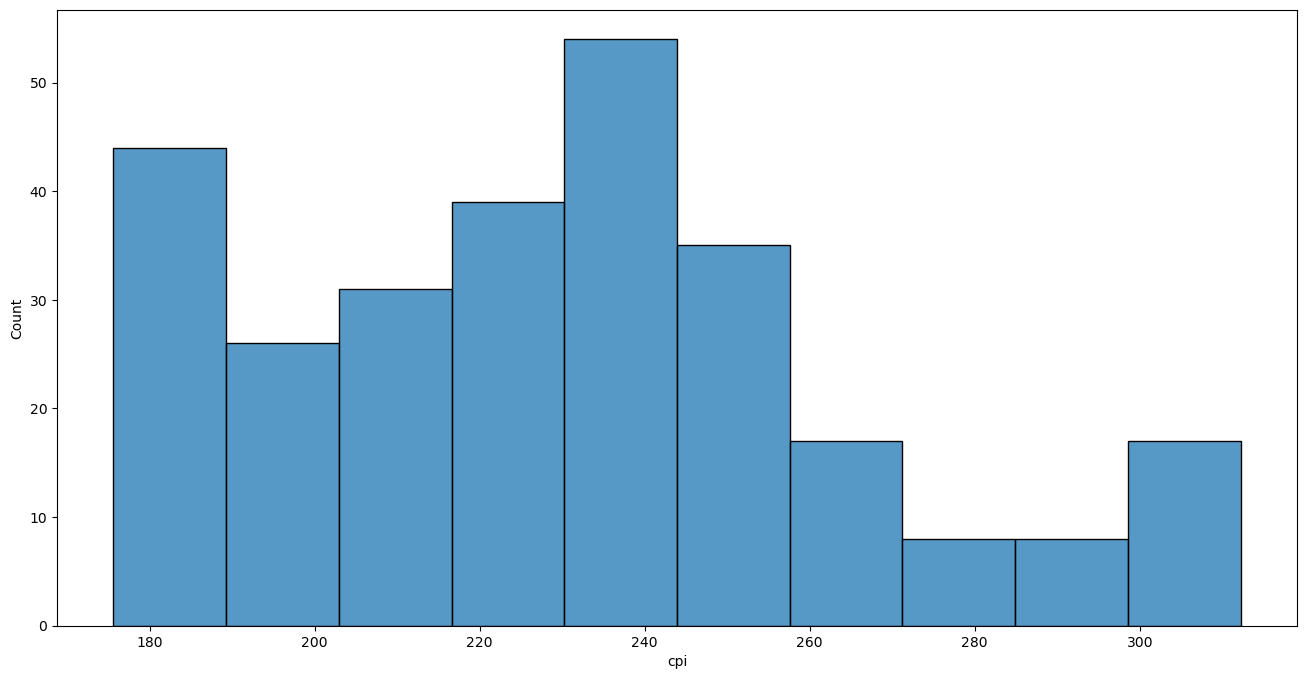

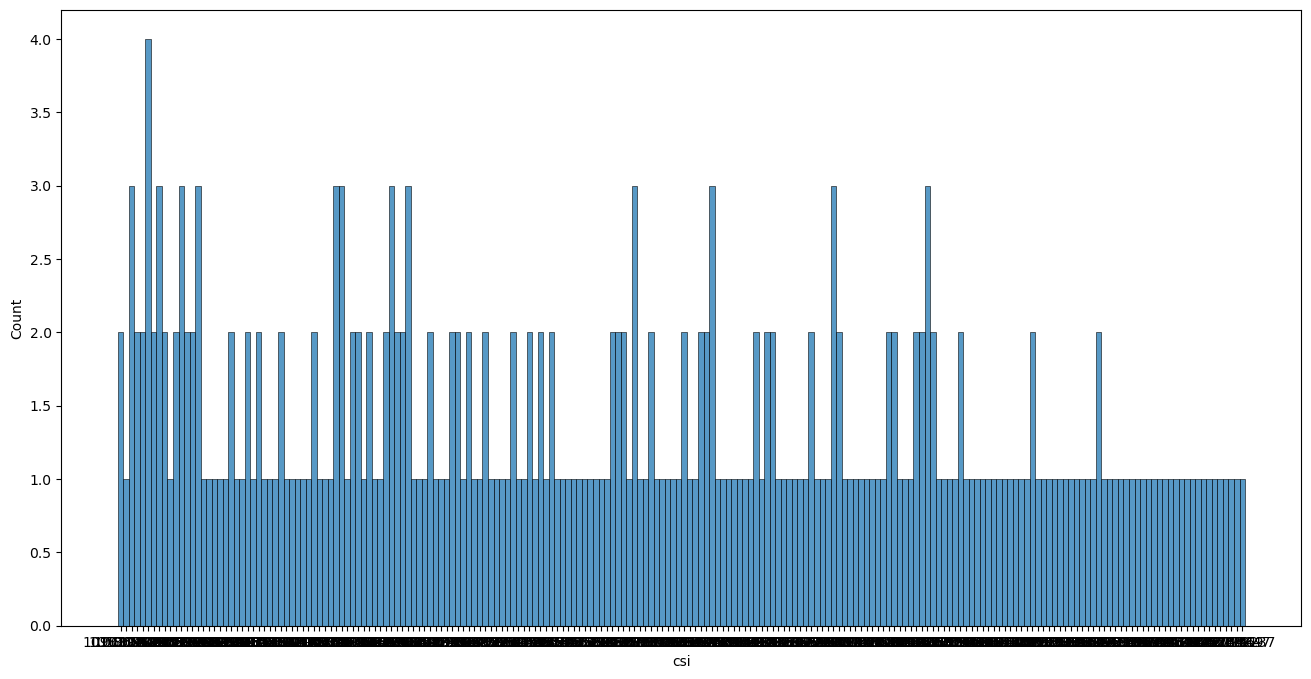

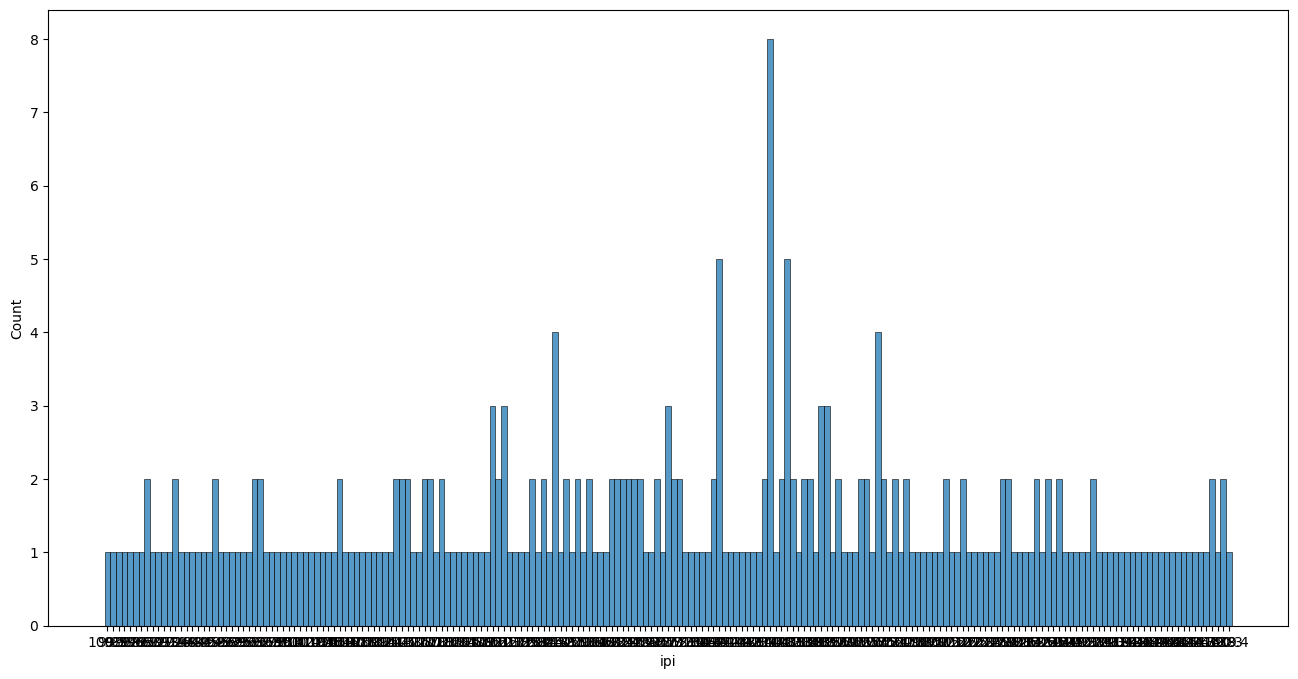

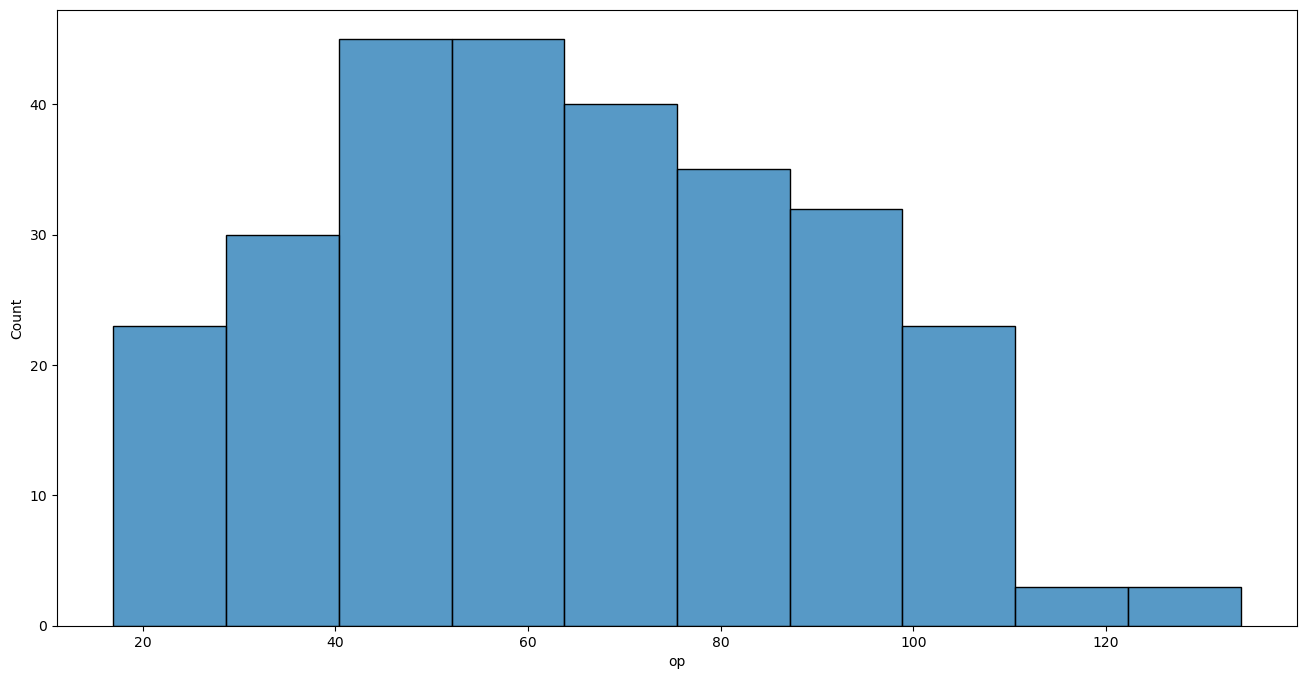

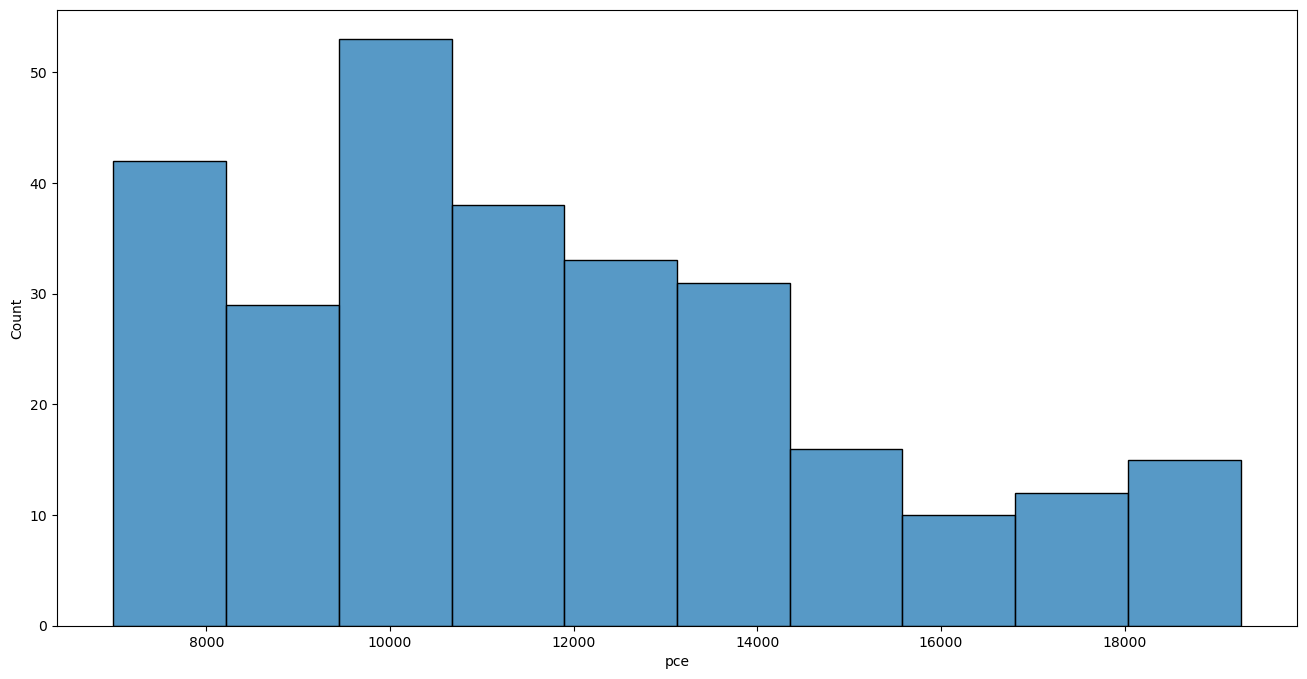

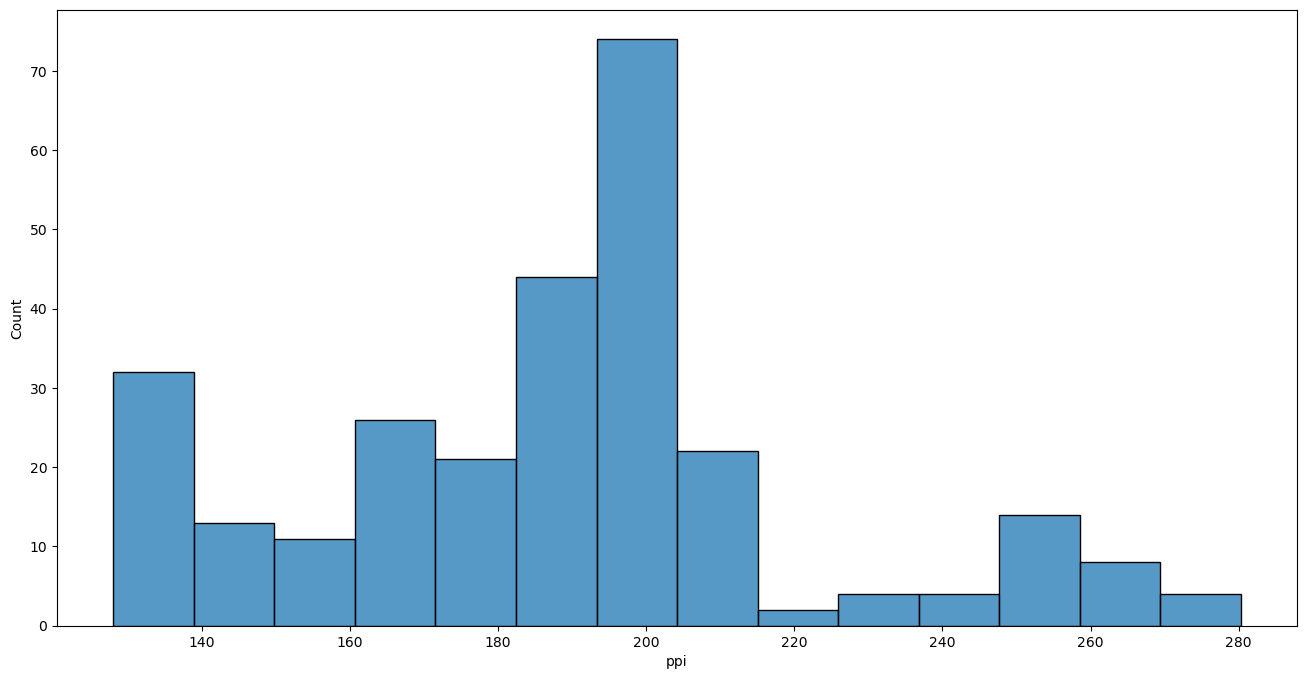

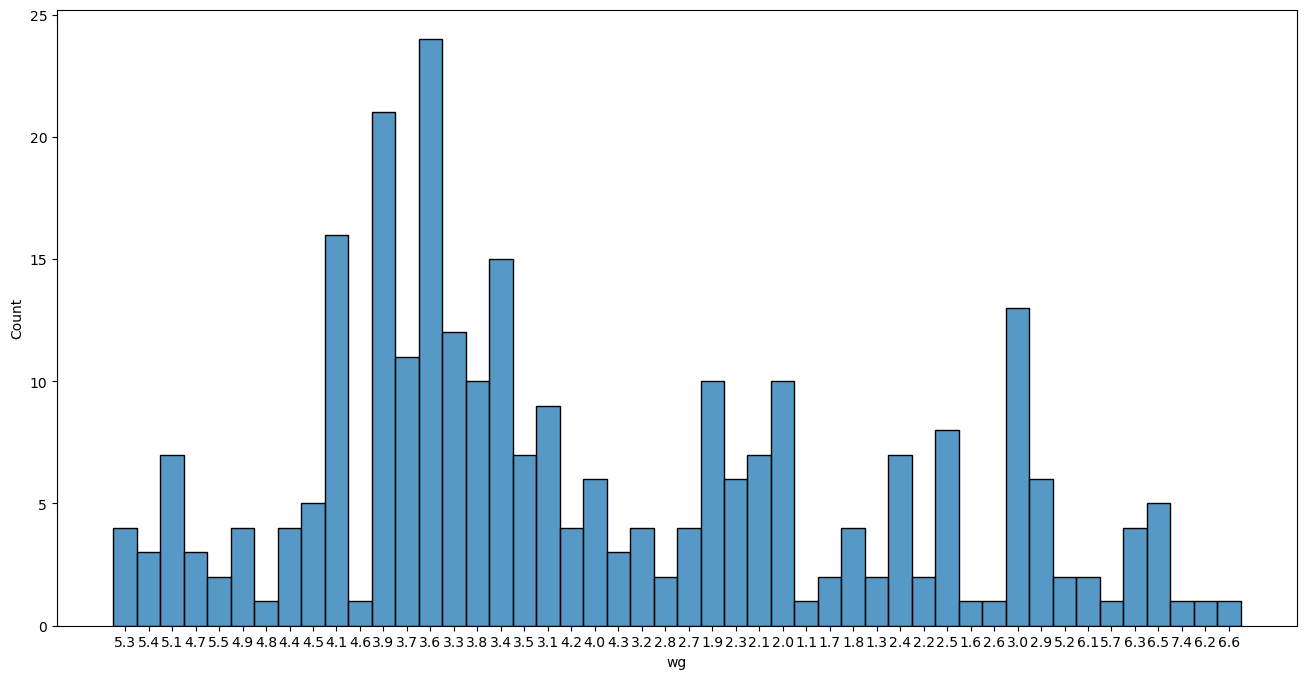

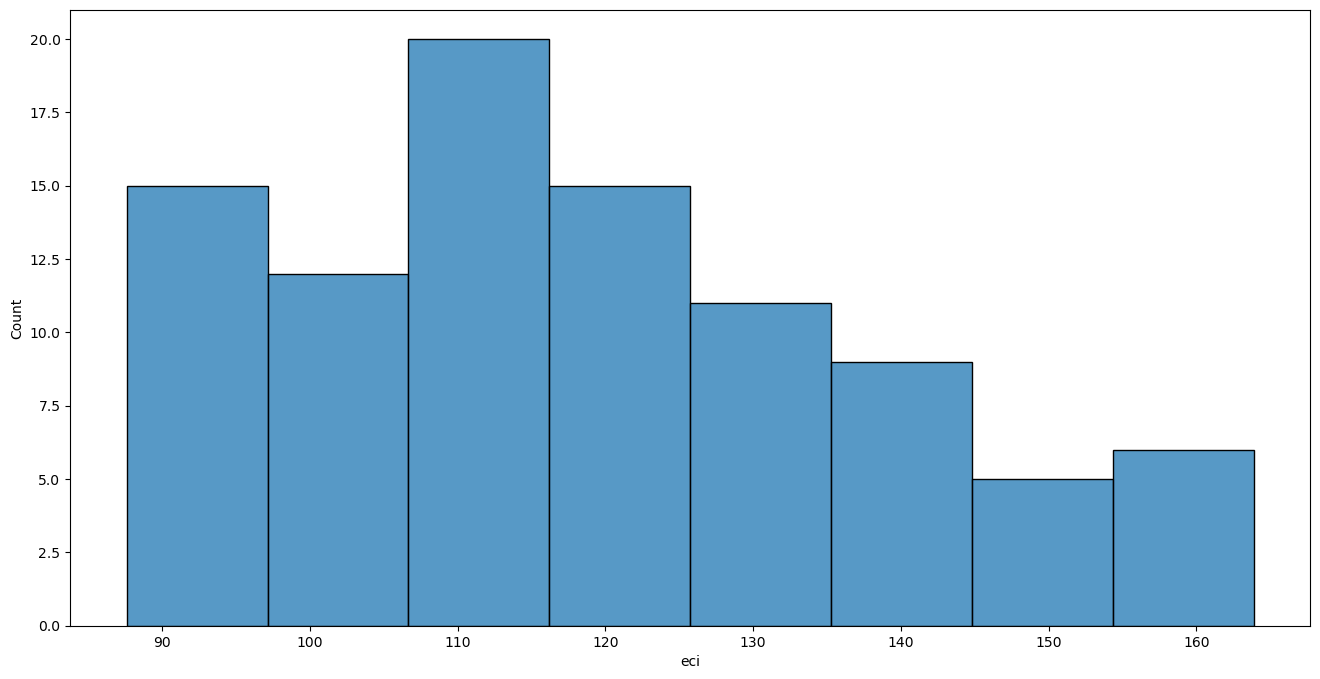

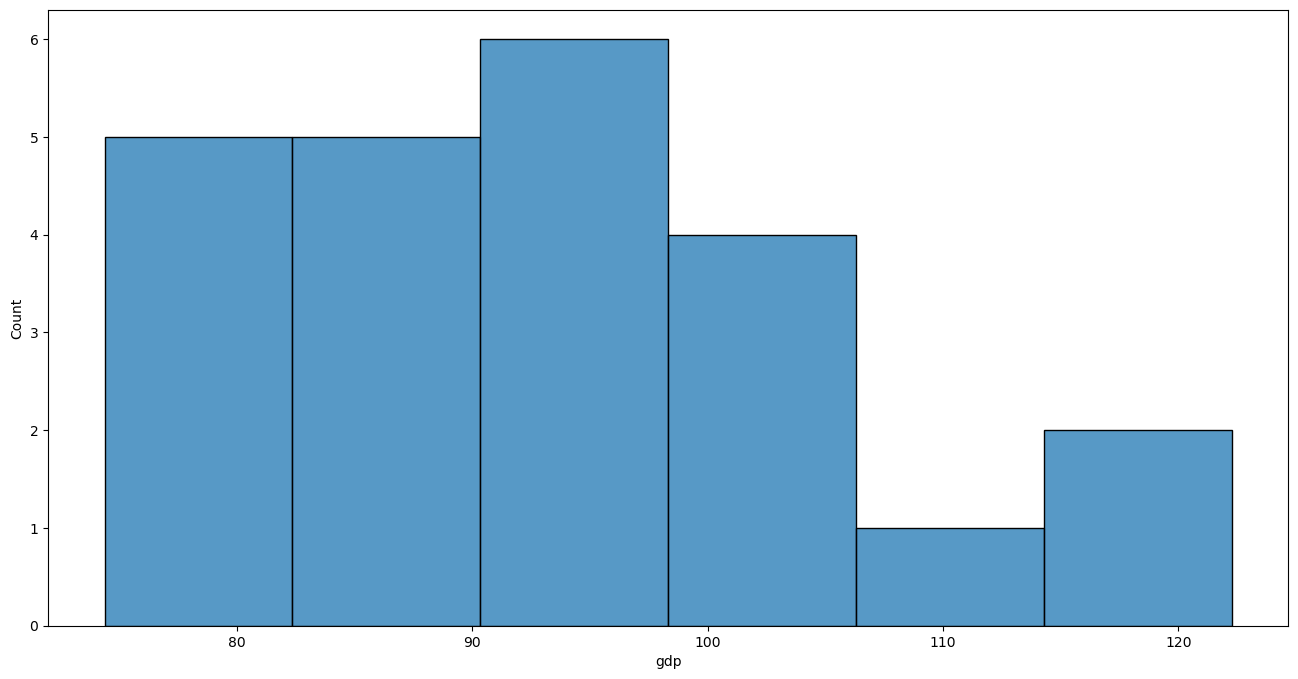

In [52]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    sns.histplot(df[column])
    plt.plot()

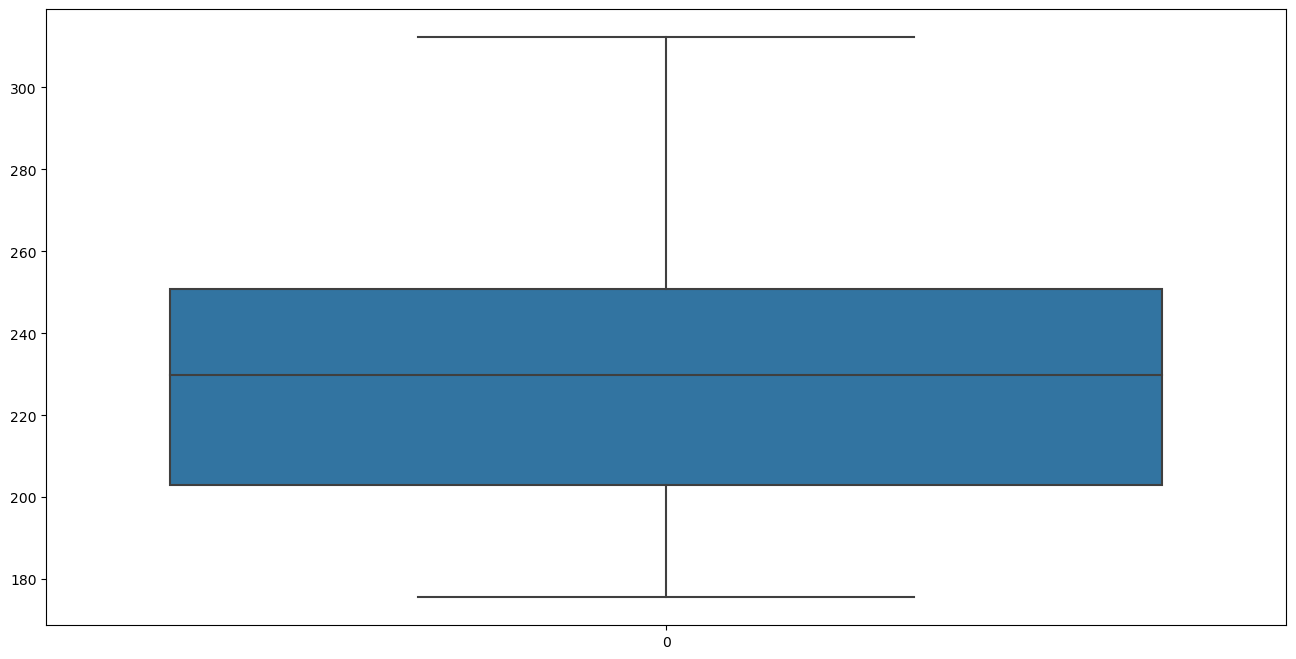

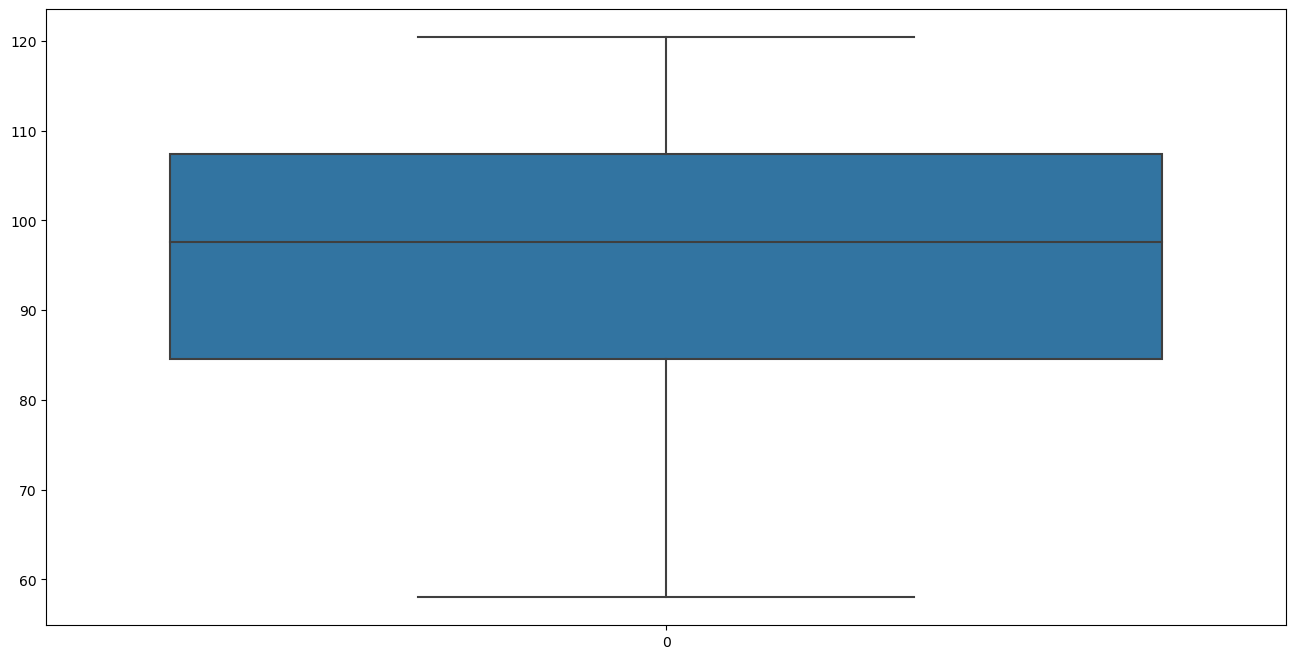

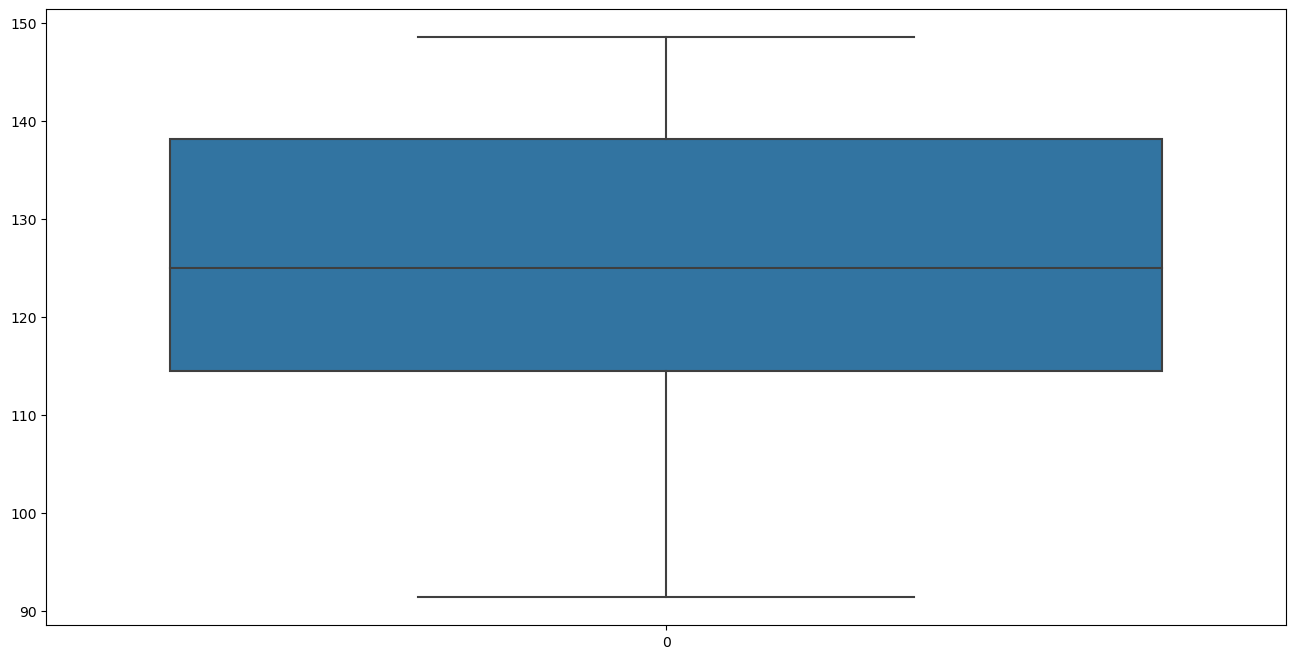

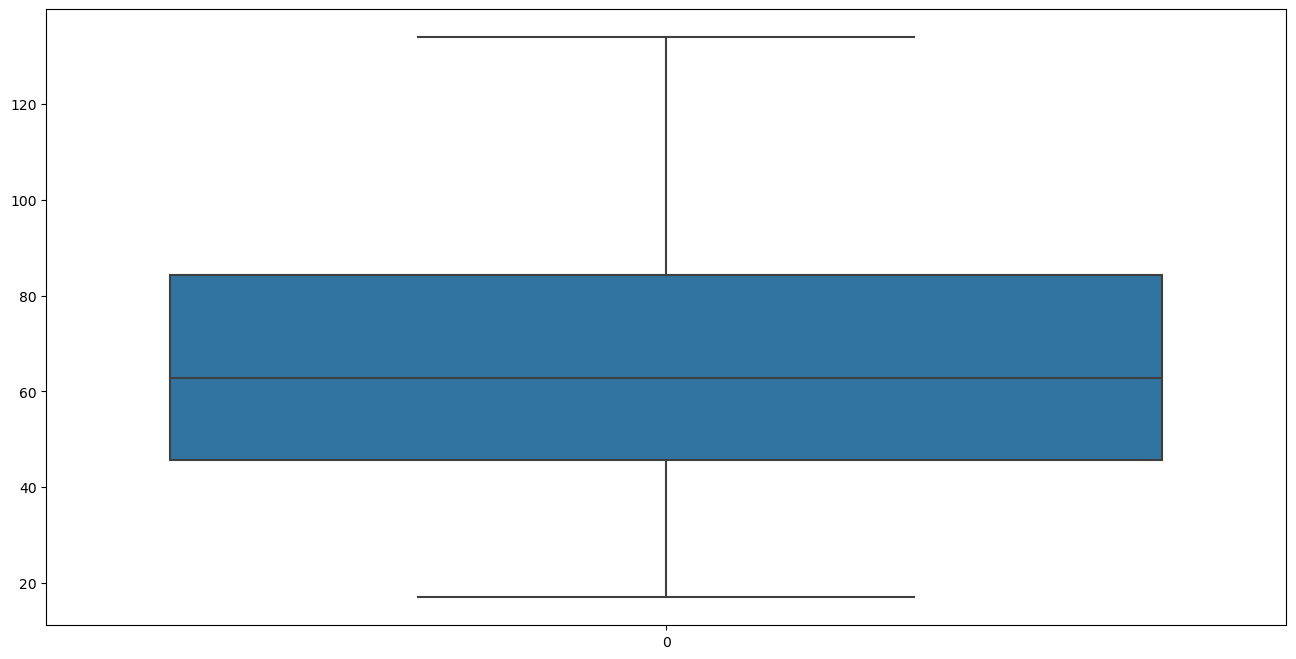

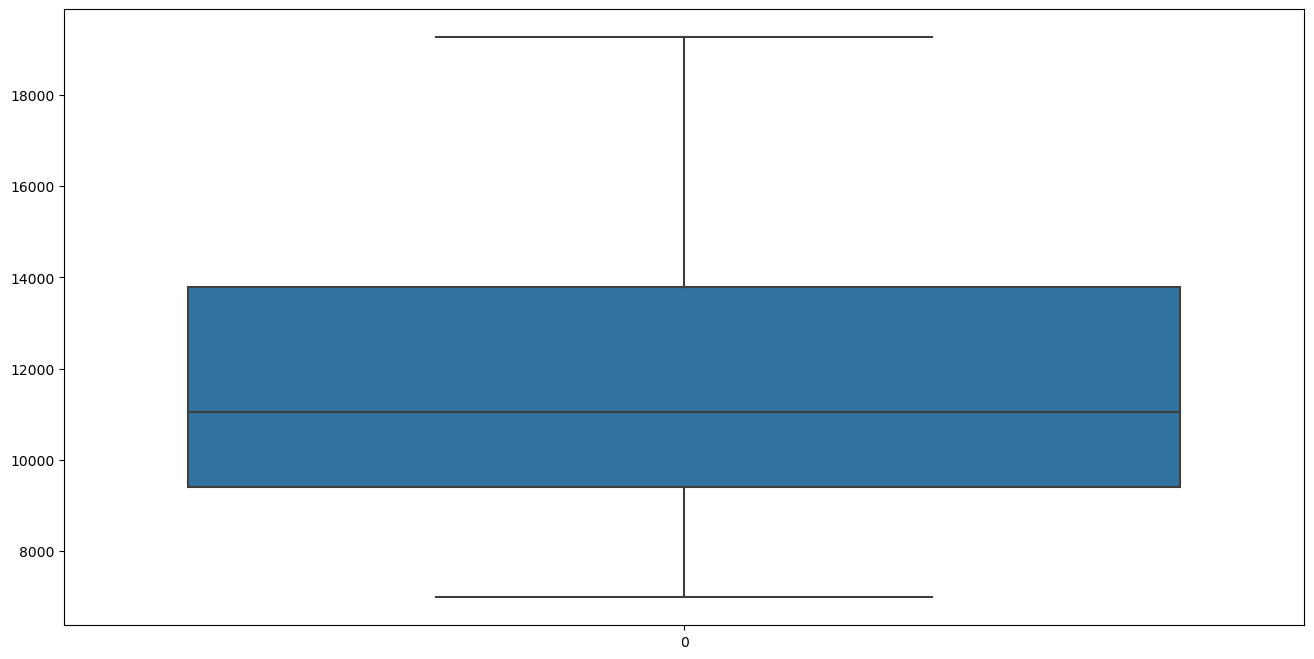

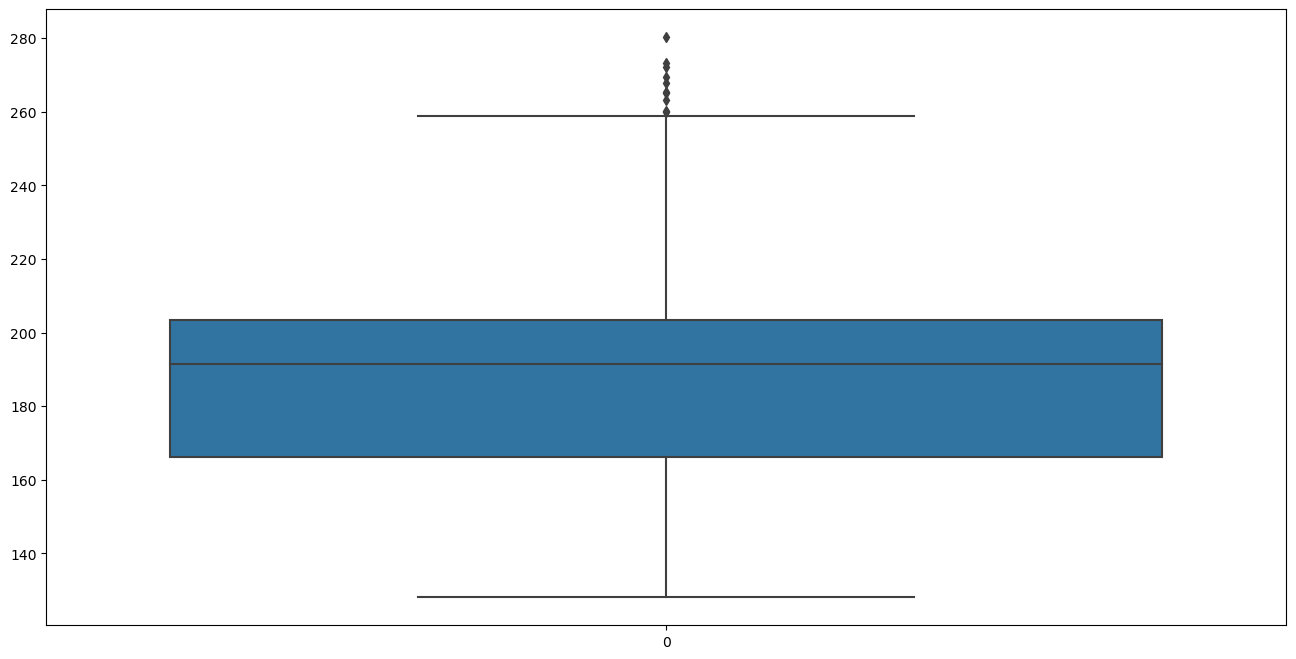

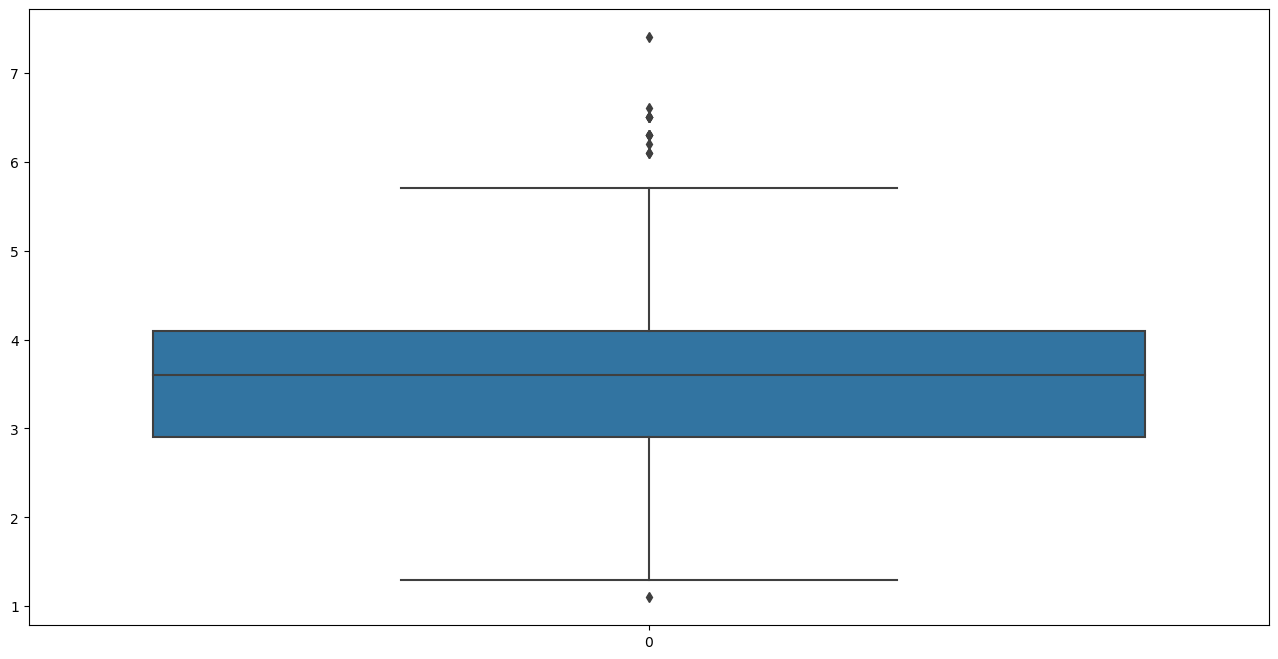

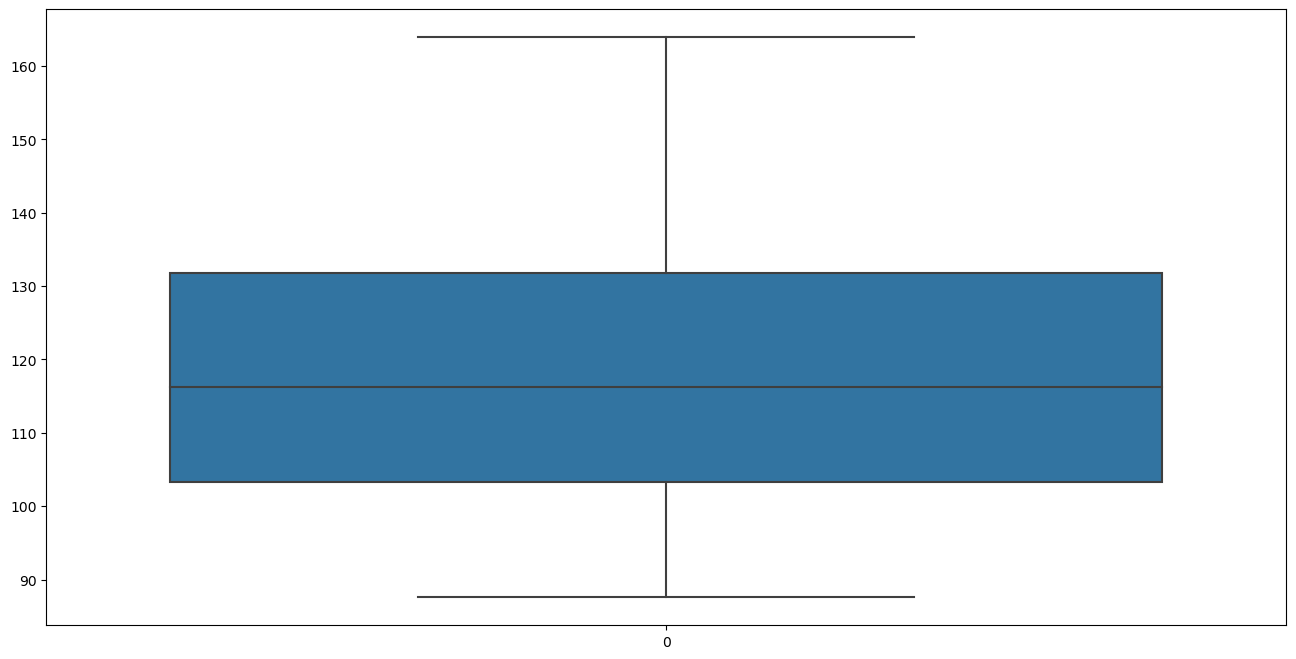

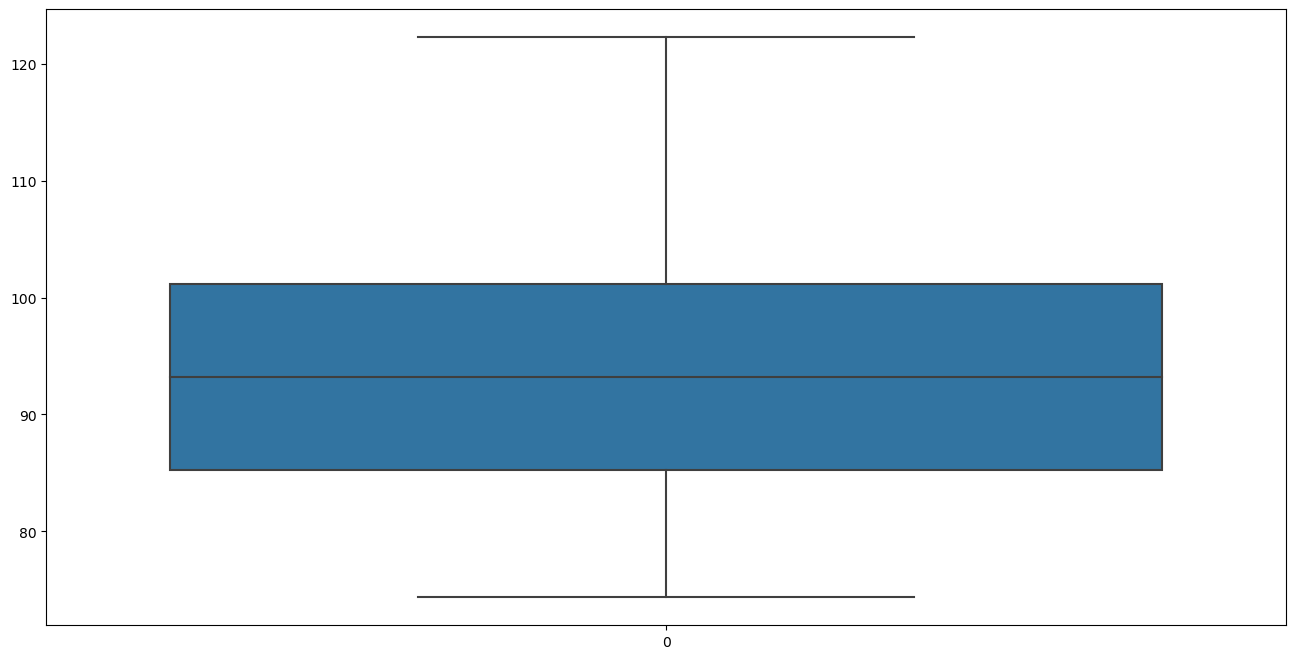

In [53]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    sns.boxplot(df[column])
    
    plt.plot()

<Axes: xlabel='DATE'>

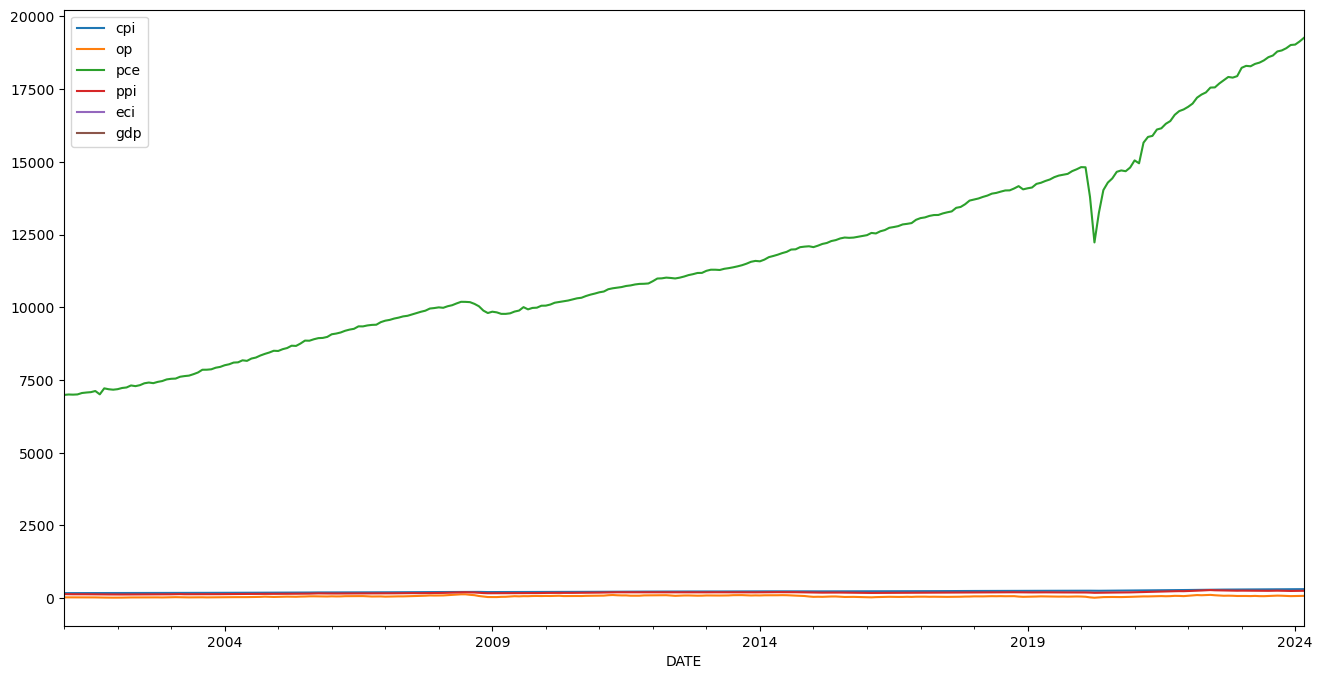

In [54]:
df.plot(figsize=(16, 8))

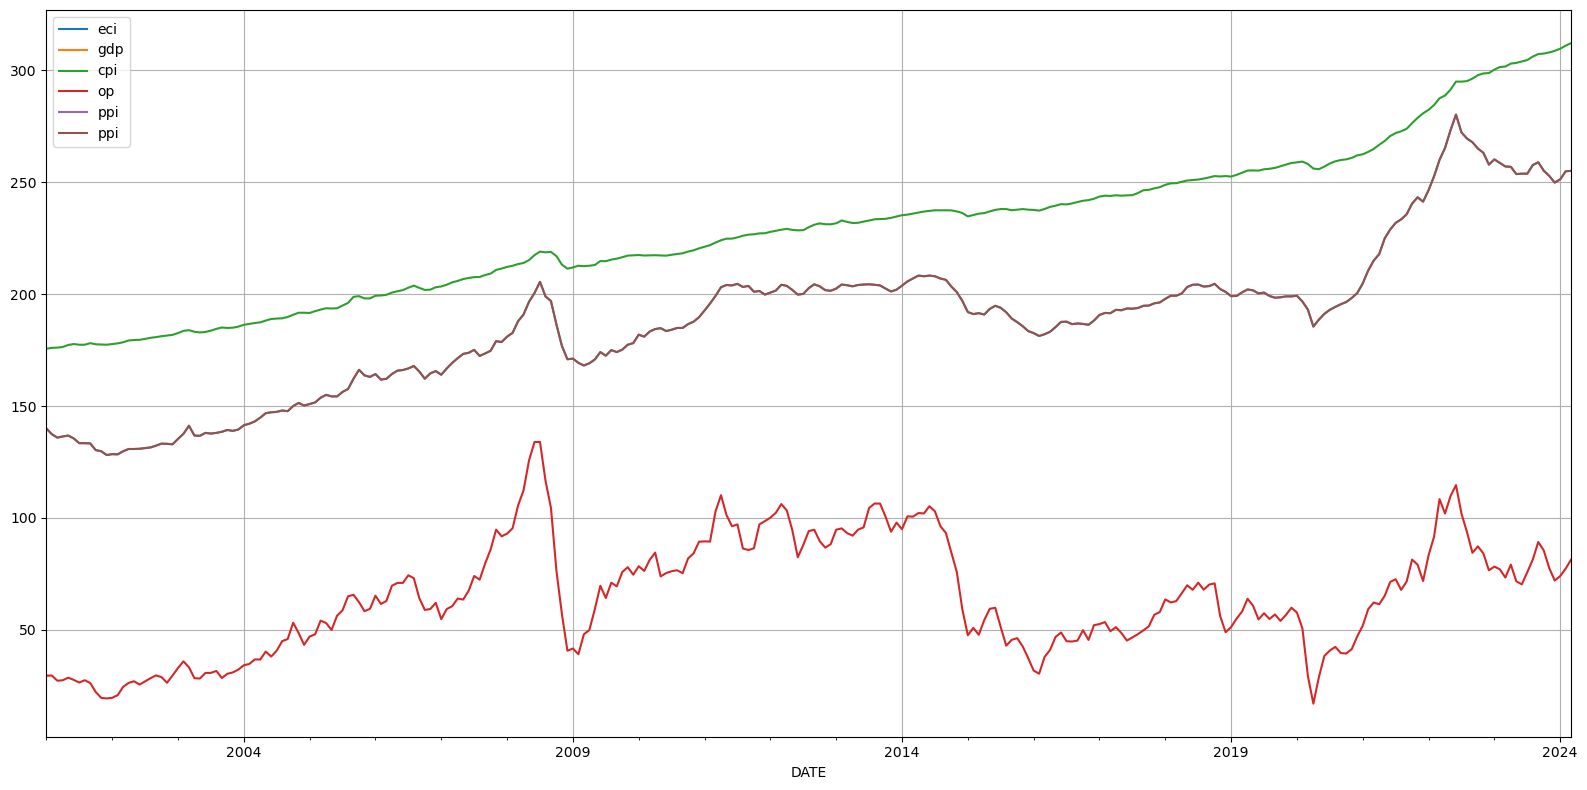

In [55]:
df[['eci','gdp','cpi','csi','op','ppi','ppi','wg']].plot(figsize=(16, 8))
plt.grid(True)
plt.tight_layout()

In [56]:
corr_matrix = df.corr()
corr_matrix

,cpi,csi,ipi,op,pce,ppi,wg,eci,gdp
cpi,1.000000,-0.323191,0.751017,0.397070,0.993228,0.947202,0.269064,0.994597,0.997012
csi,-0.323191,1.000000,-0.526457,-0.564594,-0.262494,-0.487579,-0.112869,-0.267248,-0.351973
ipi,0.751017,-0.526457,1.000000,0.864806,0.692604,0.892379,-0.117146,0.697173,0.760634
op,0.397070,-0.564594,0.864806,1.000000,0.333830,0.640514,-0.180450,0.326078,0.411584
pce,0.993228,-0.262494,0.692604,0.333830,1.000000,0.922378,0.325395,0.992984,0.996007
ppi,0.947202,-0.487579,0.892379,0.640514,0.922378,1.000000,0.214811,0.913650,0.947419
wg,0.269064,-0.112869,-0.117146,-0.180450,0.325395,0.214811,1.000000,0.247082,0.180082
eci,0.994597,-0.267248,0.697173,0.326078,0.992984,0.913650,0.247082,1.000000,0.995655
gdp,0.997012,-0.351973,0.760634,0.411584,0.996007,0.947419,0.180082,0.995655,1.000000


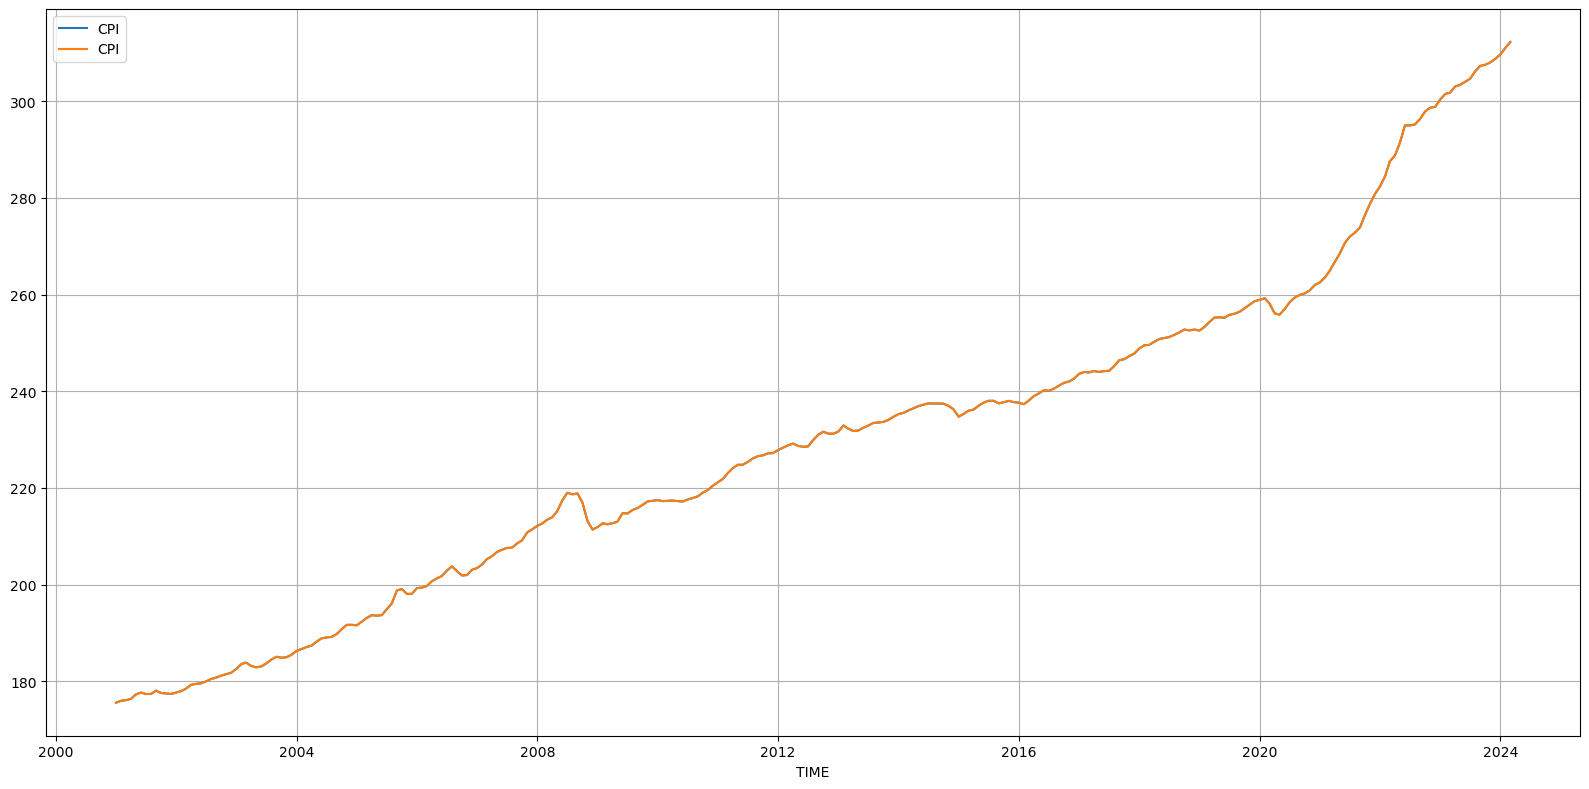

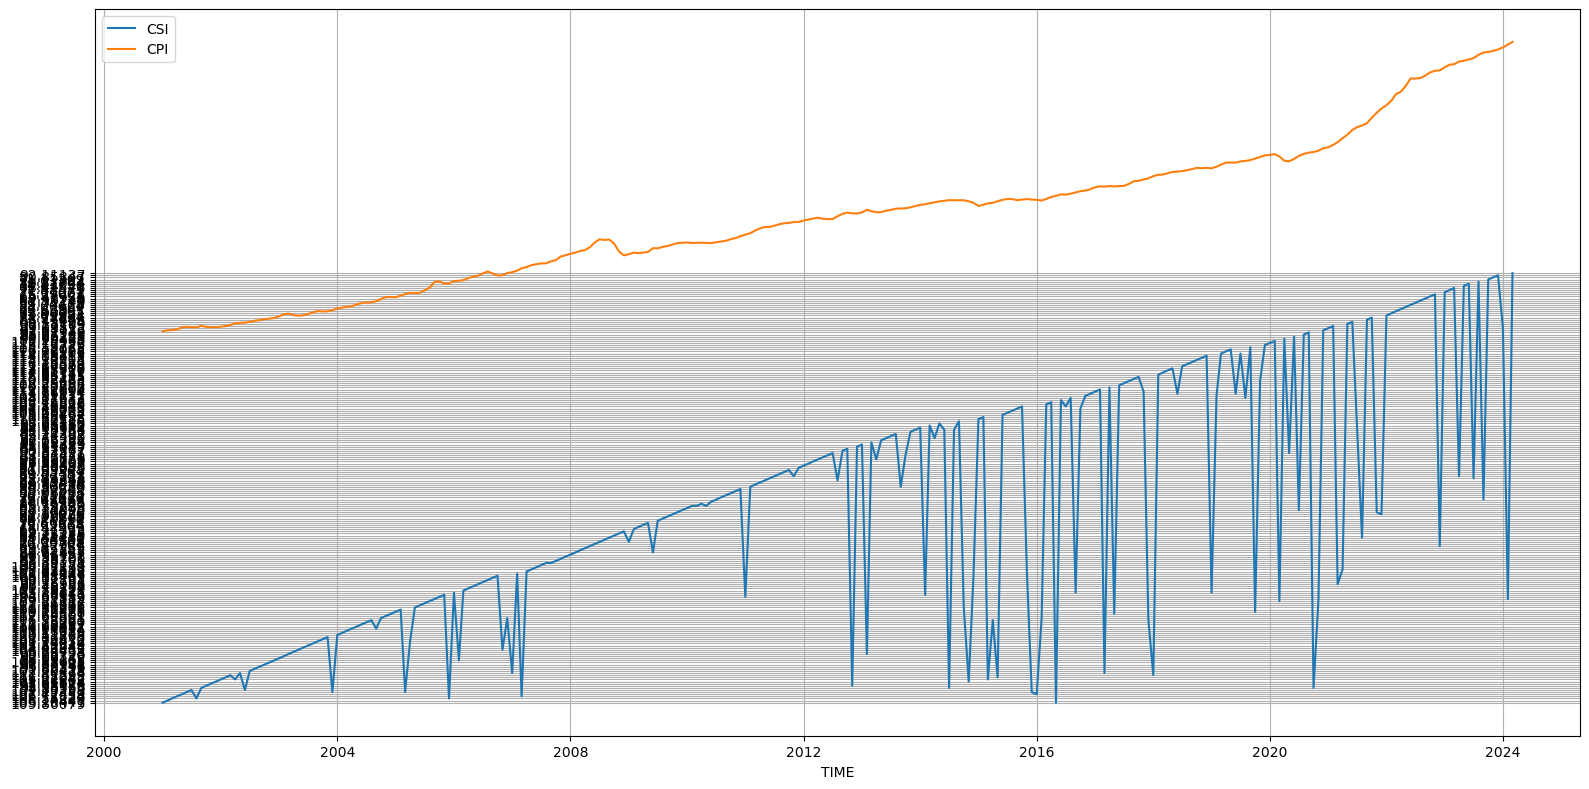

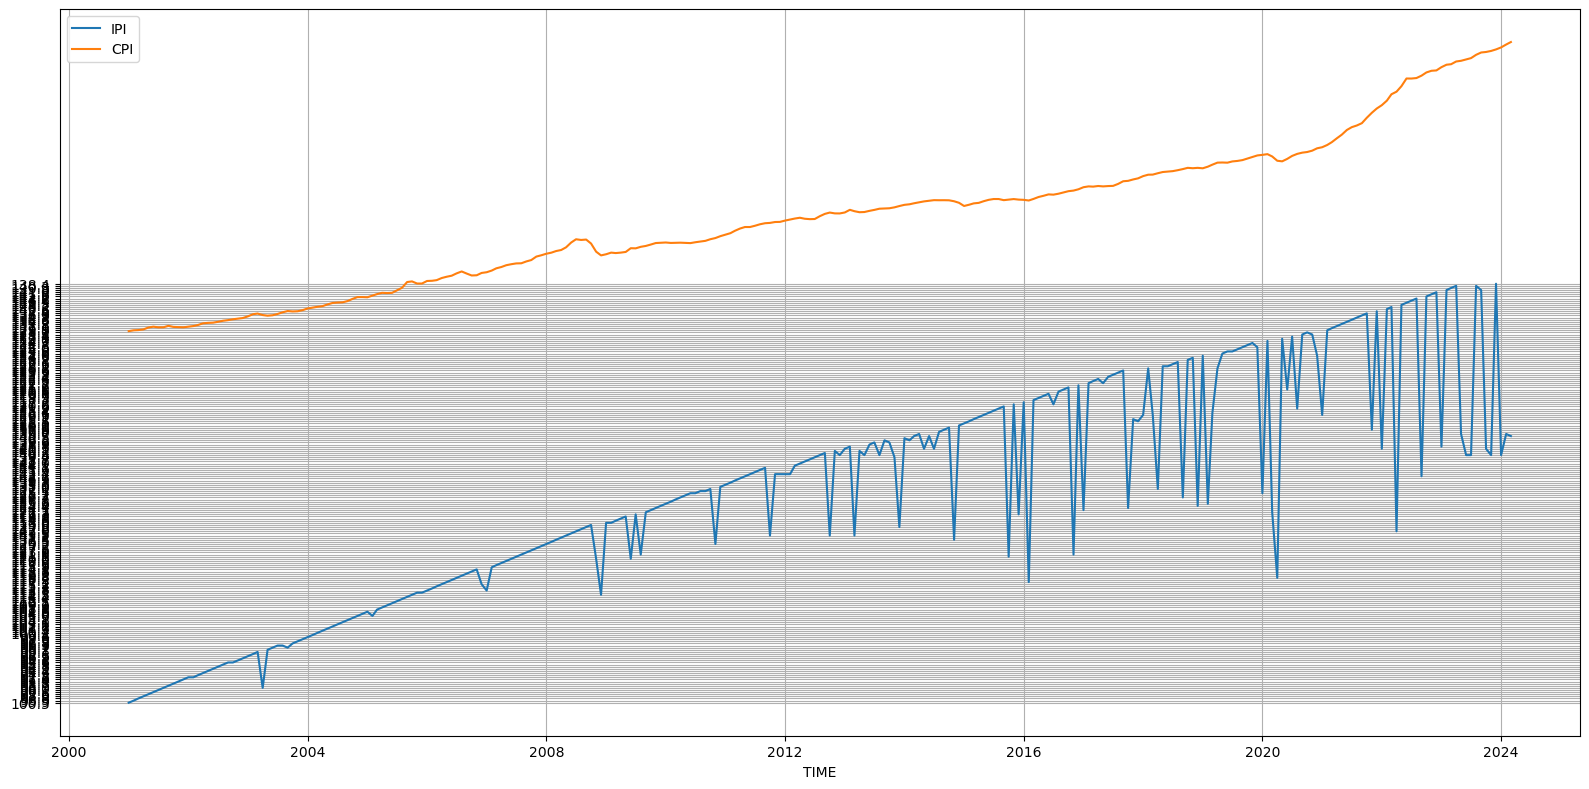

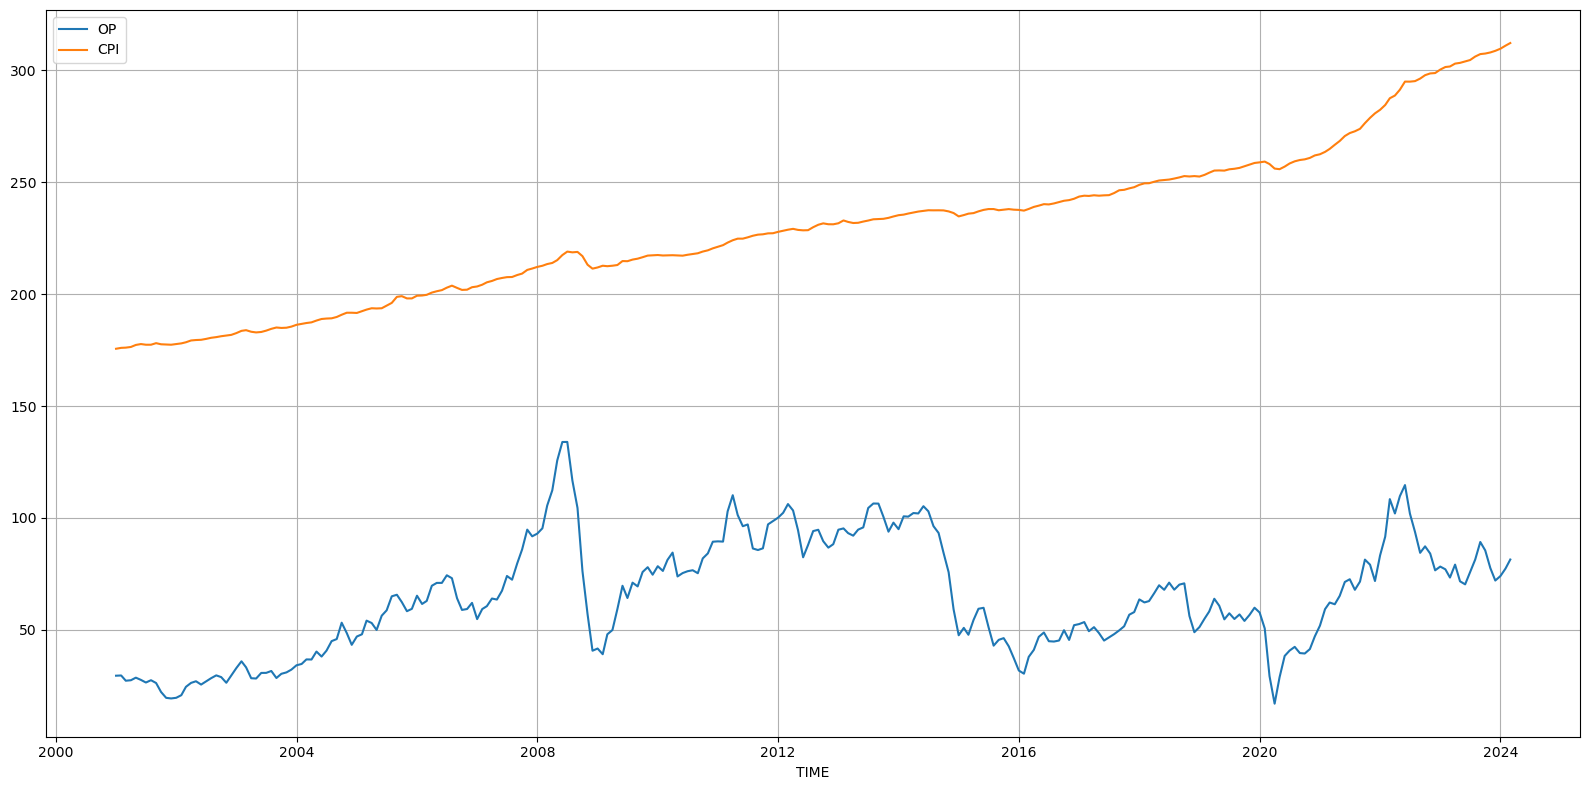

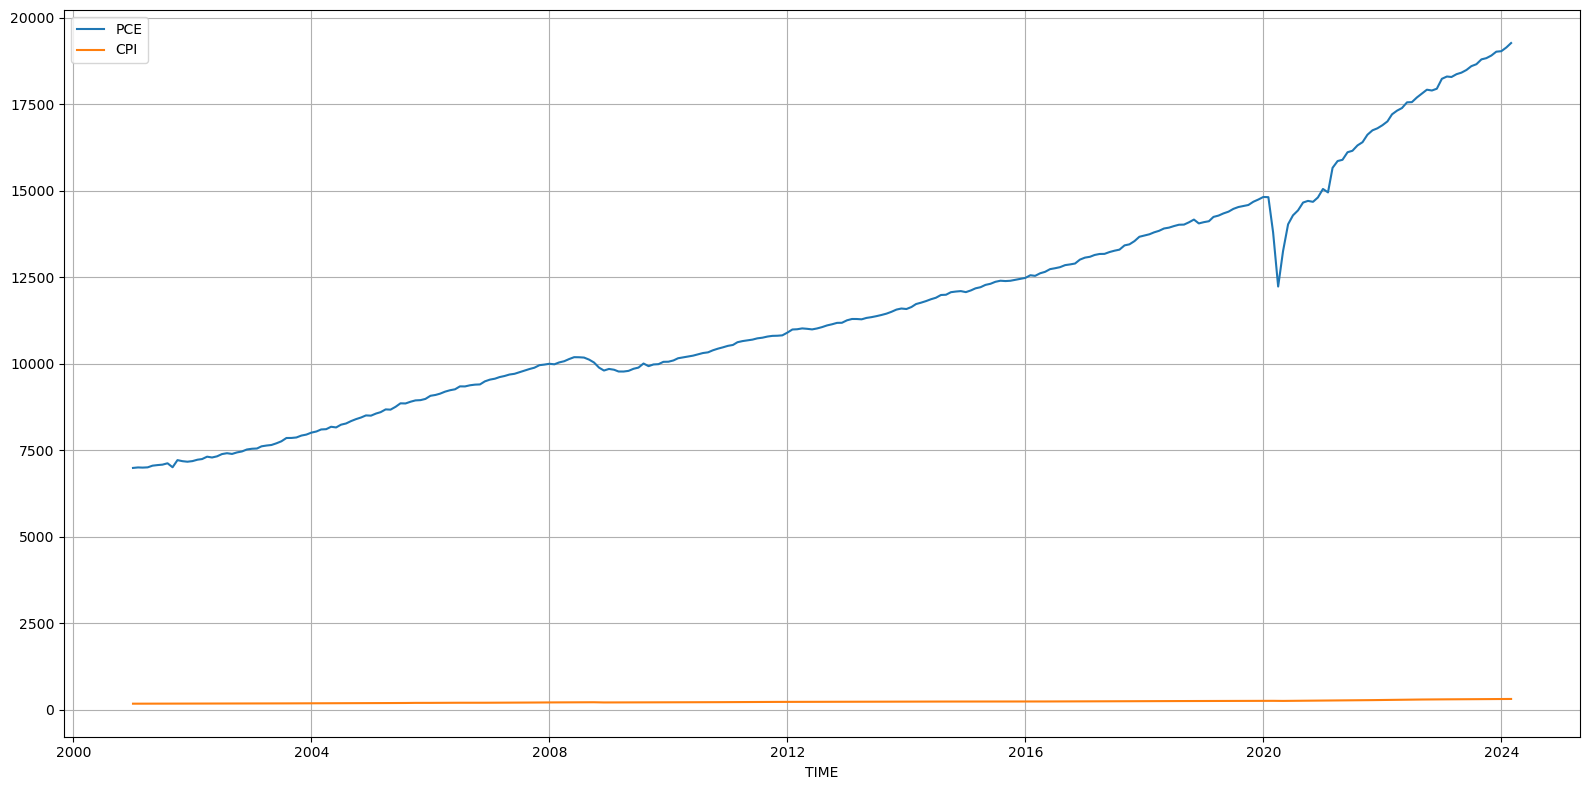

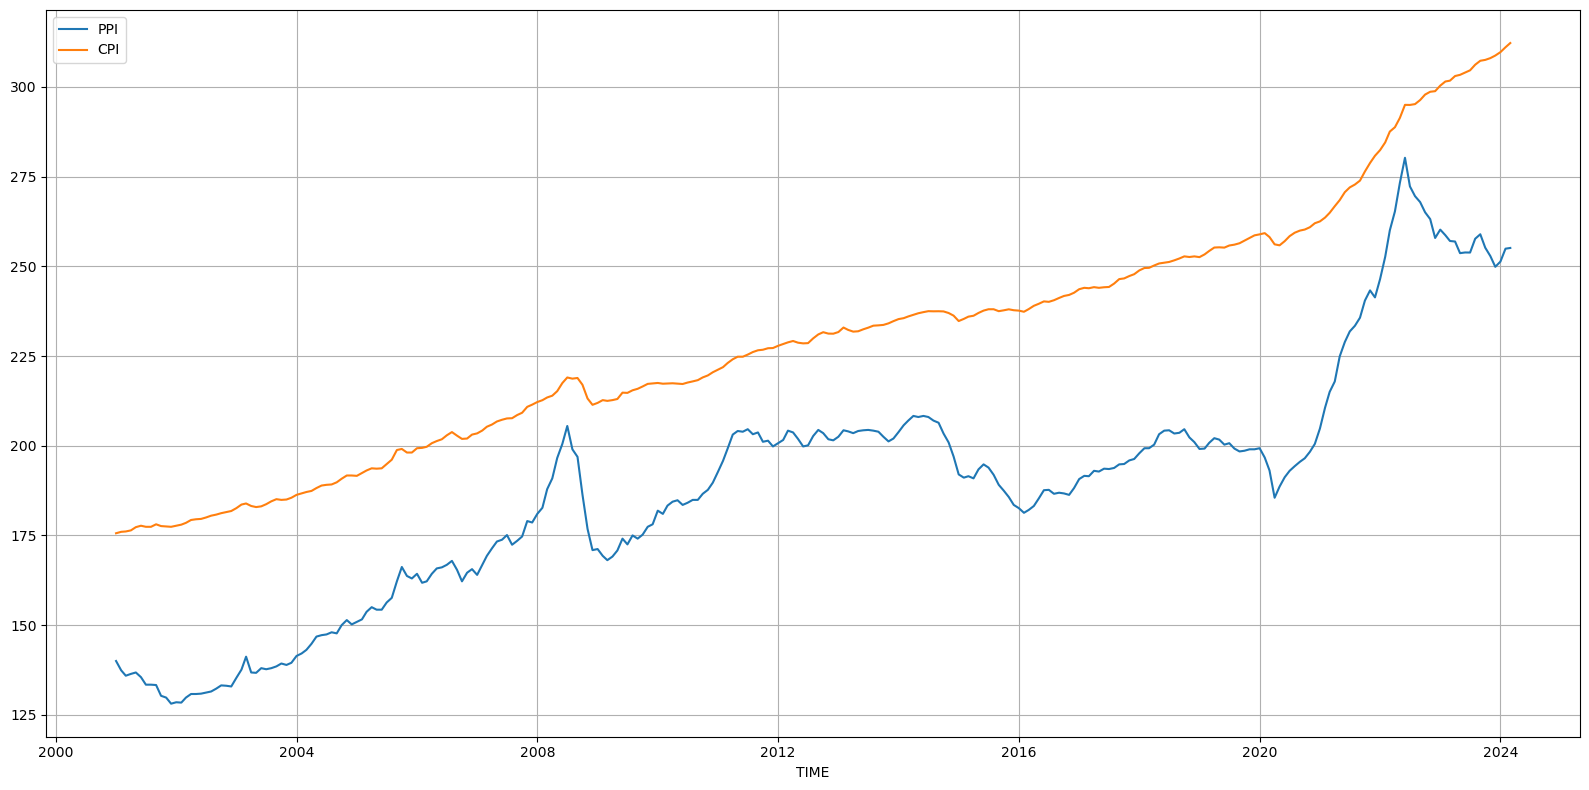

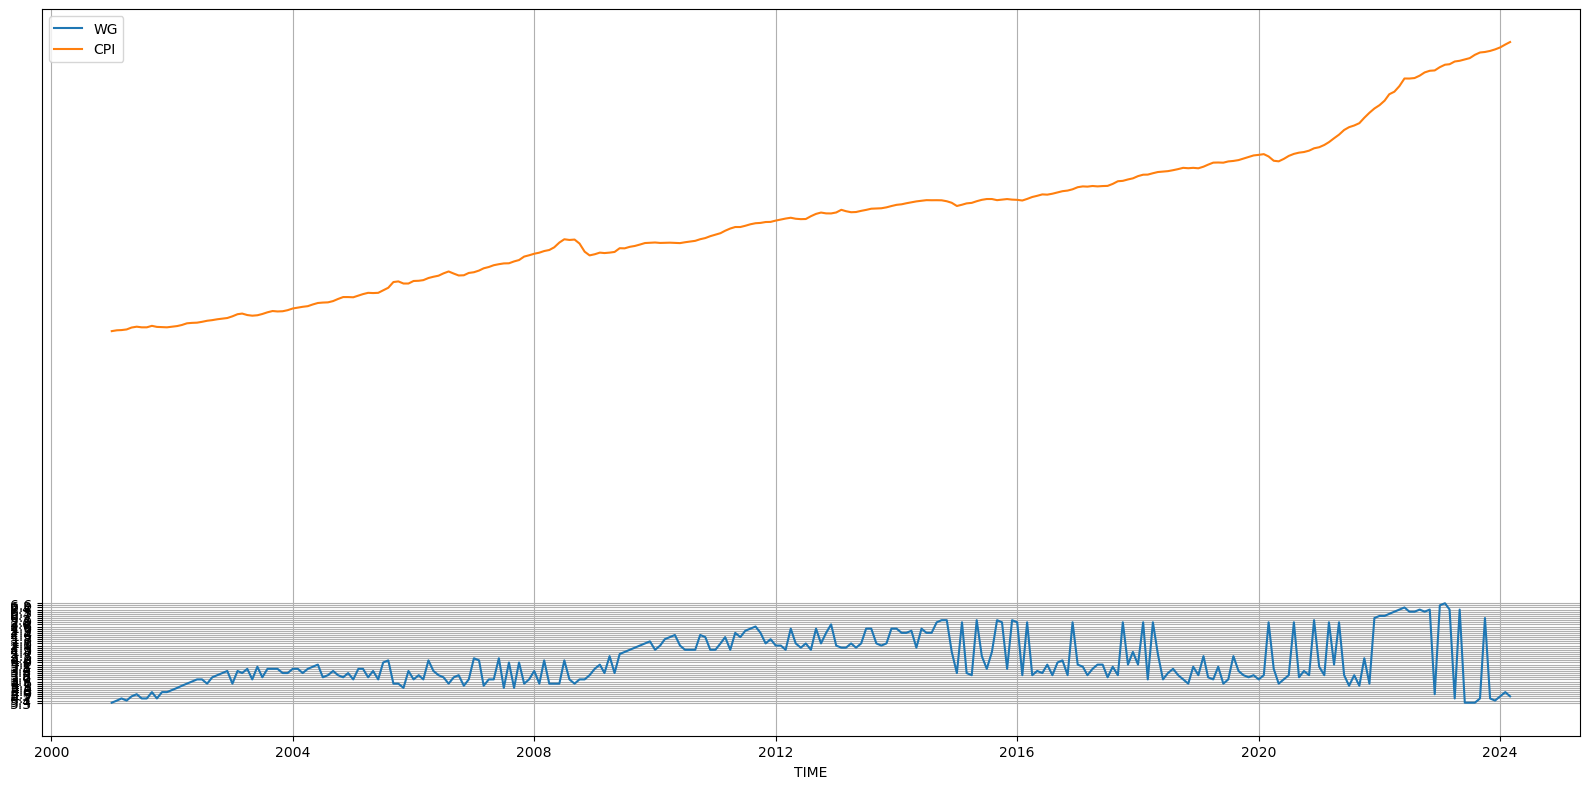

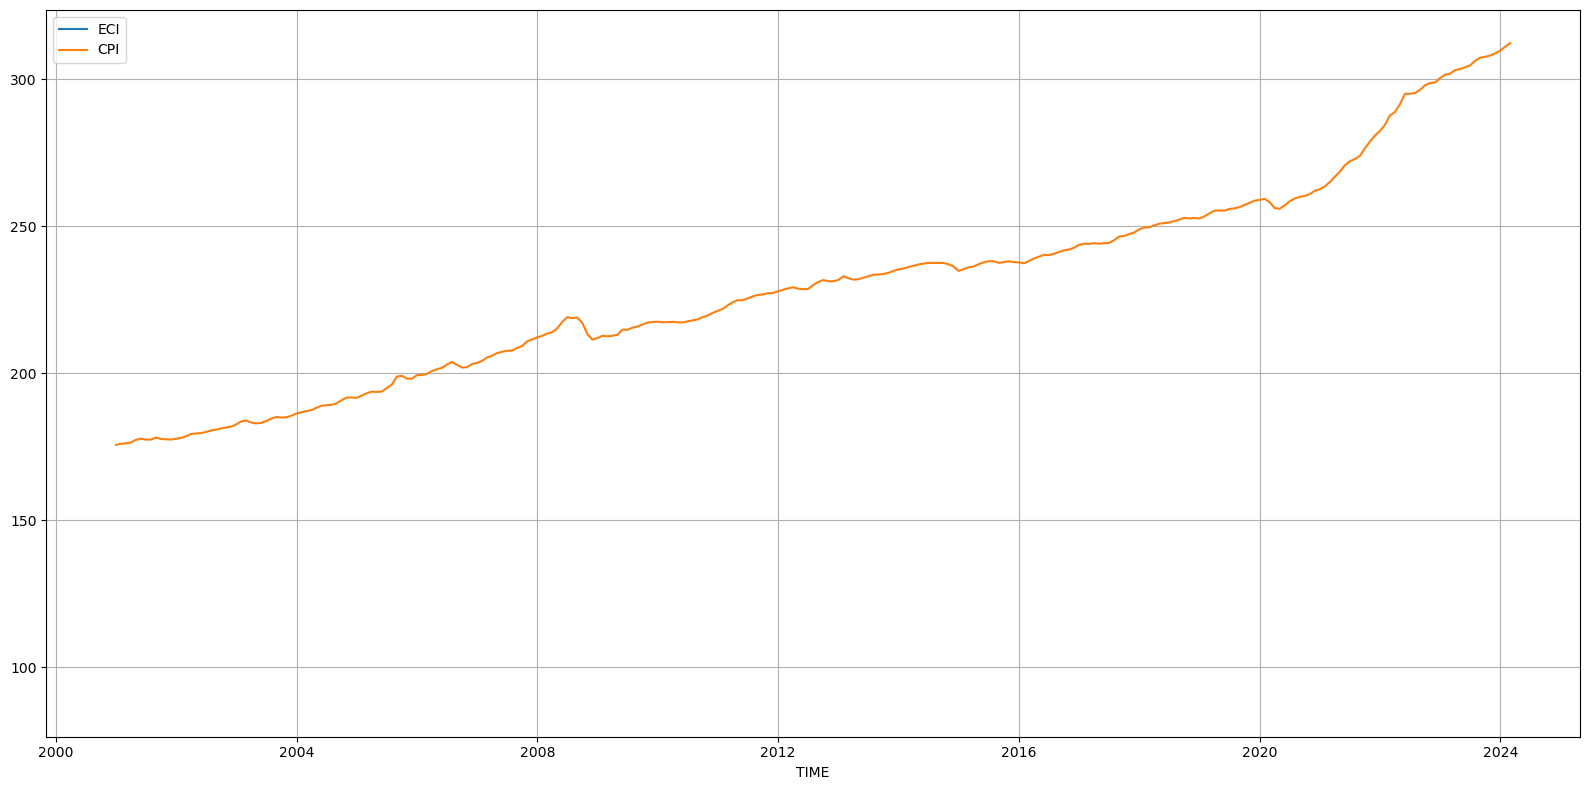

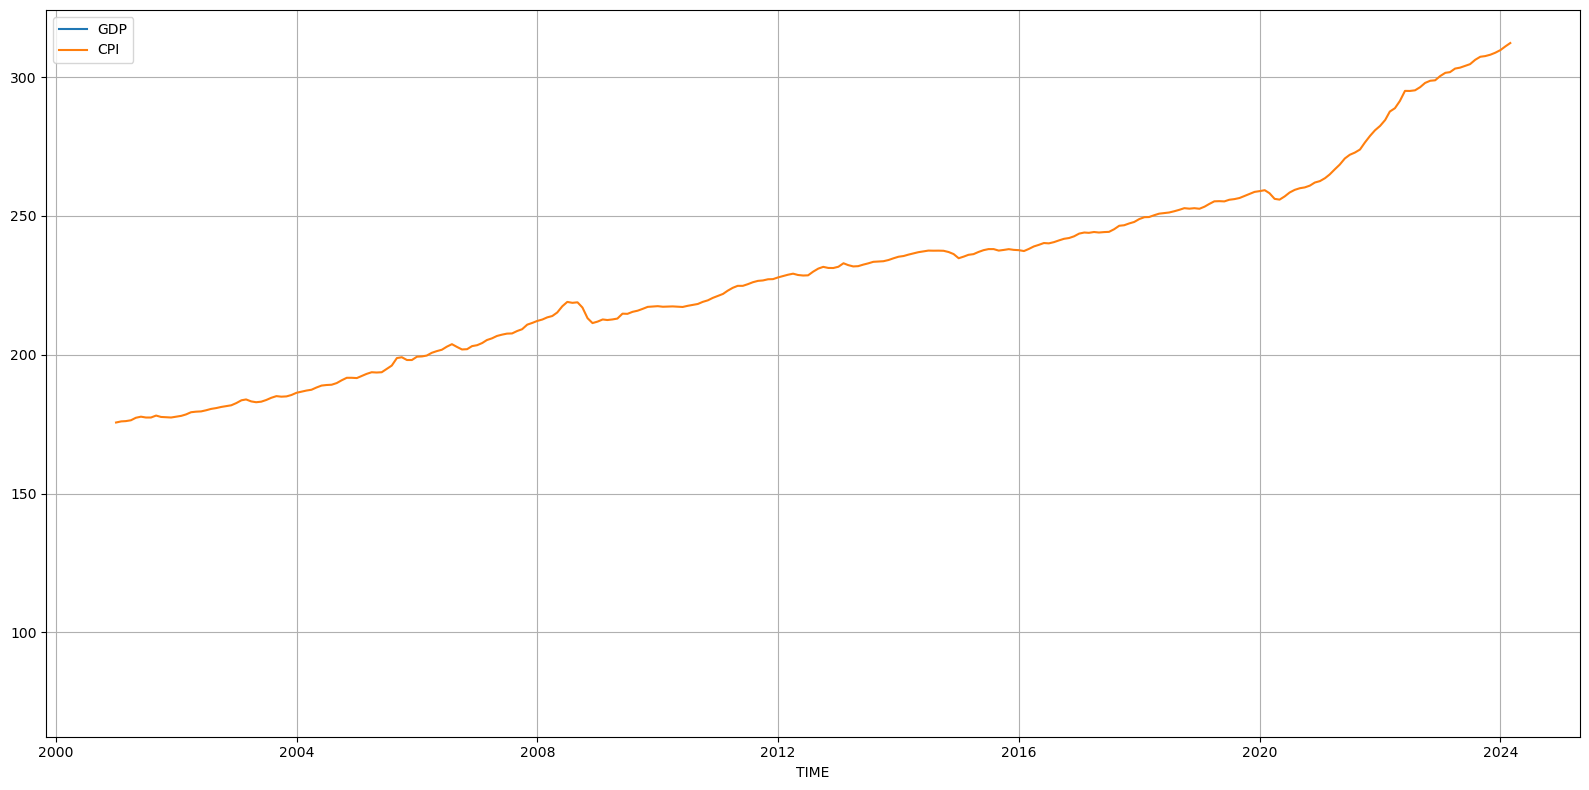

In [57]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    plt.plot(df[column], label=column.upper())
    plt.plot(df['cpi'], label='CPI')
    plt.xlabel('TIME')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


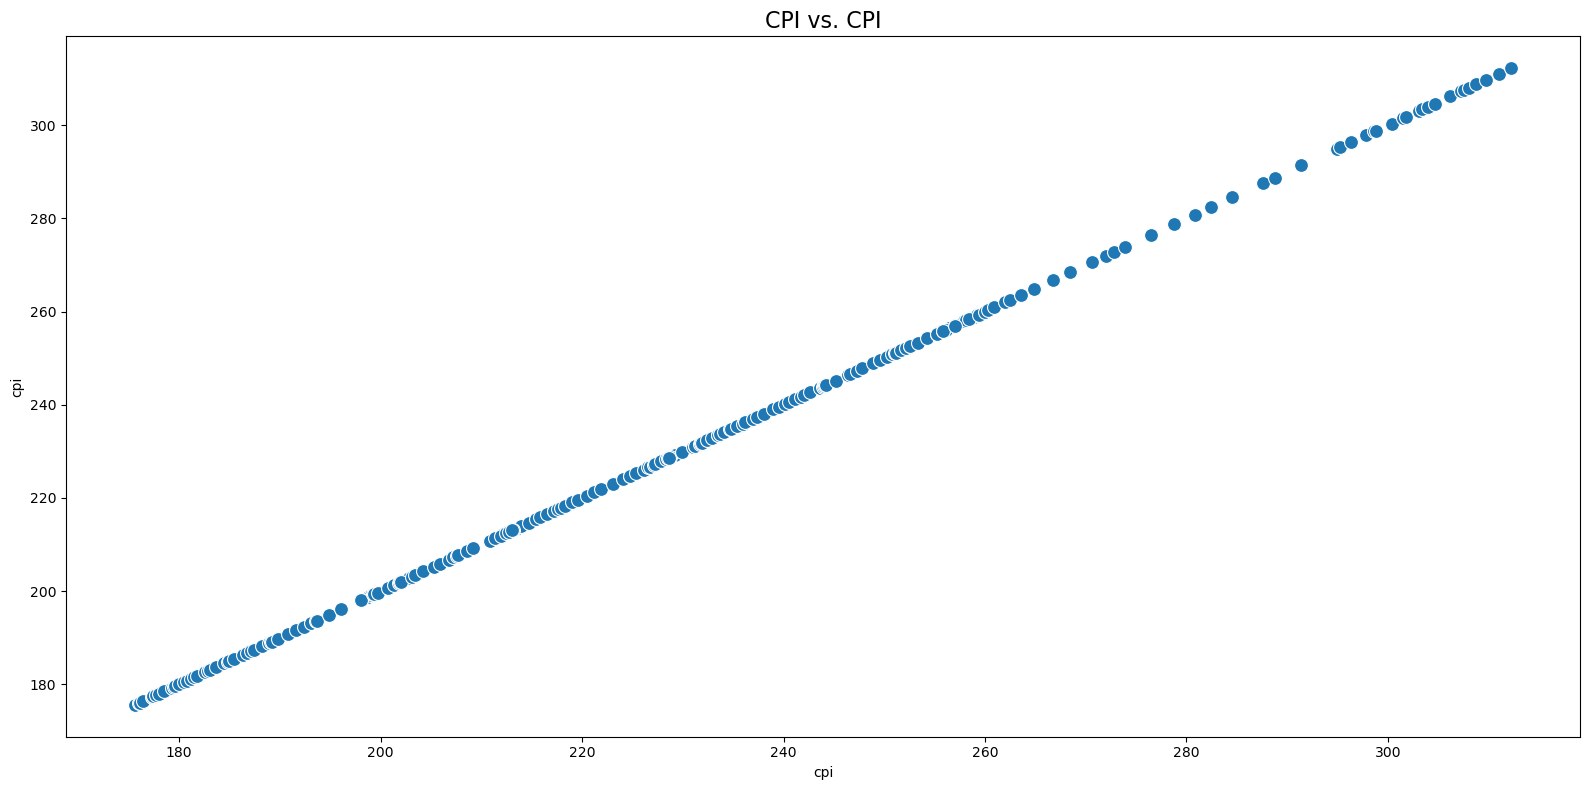

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


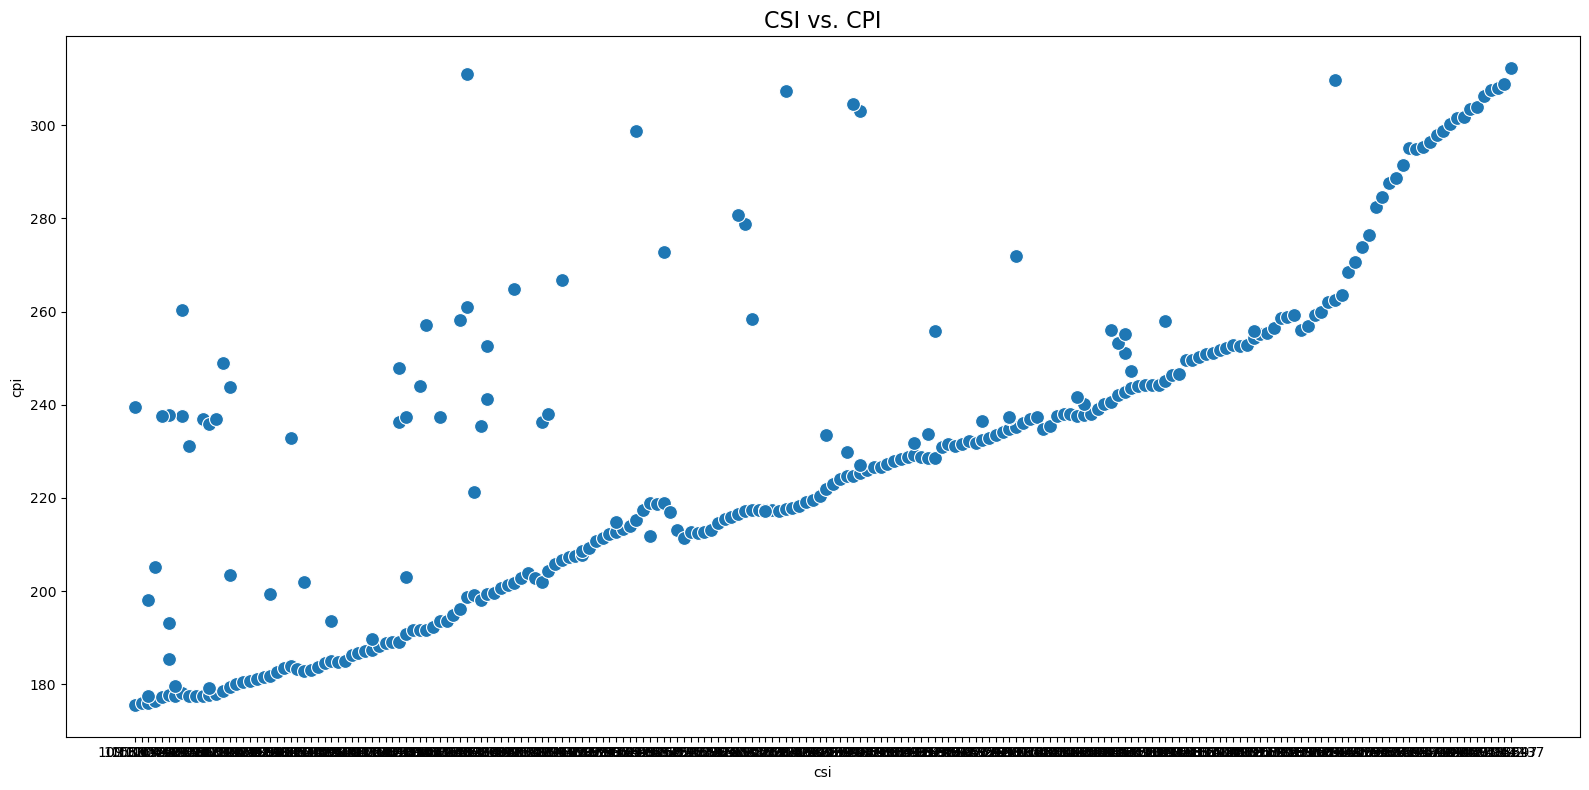

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


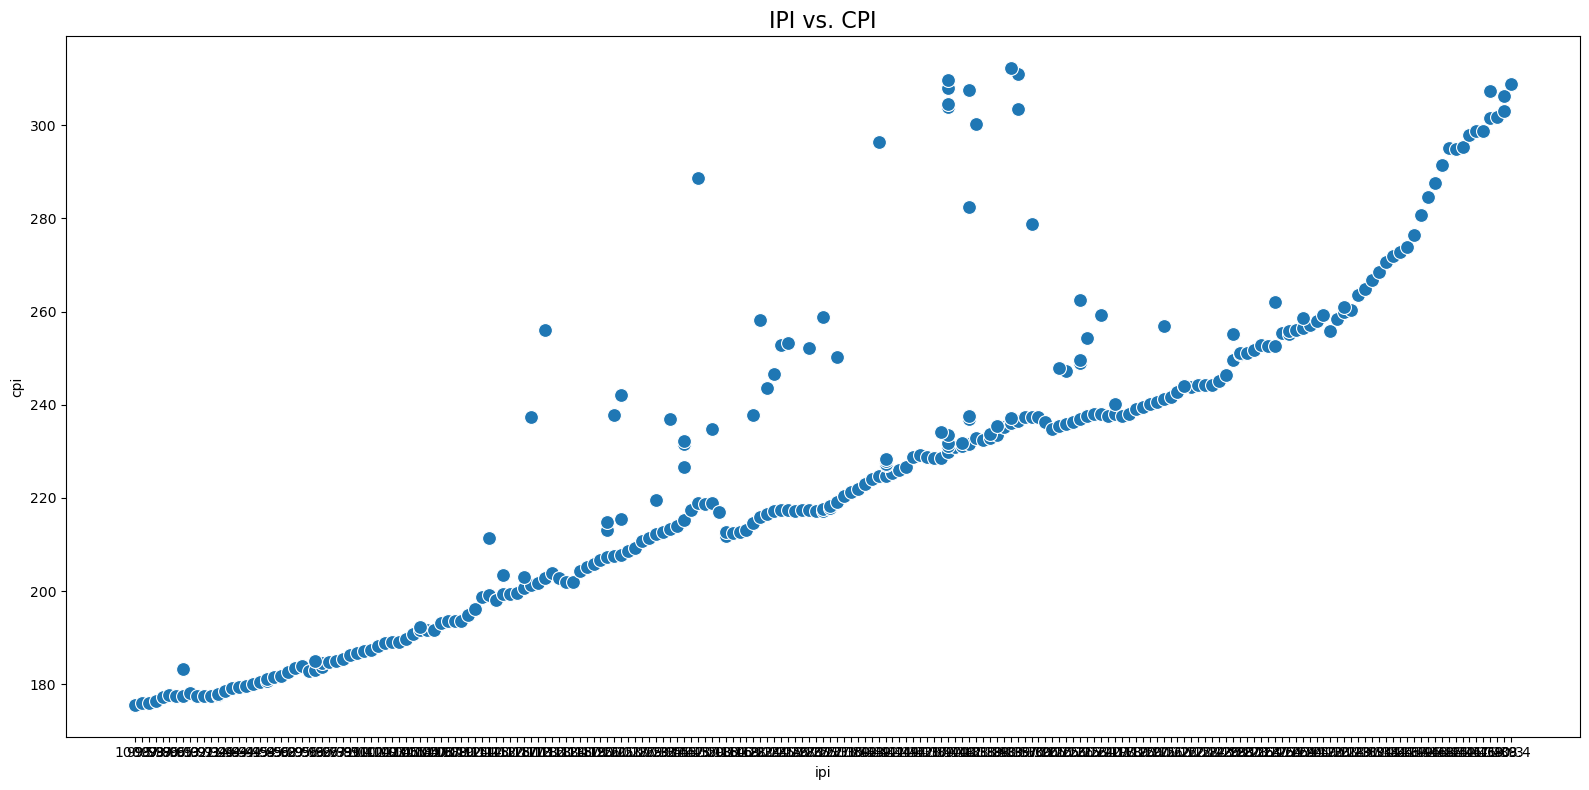

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


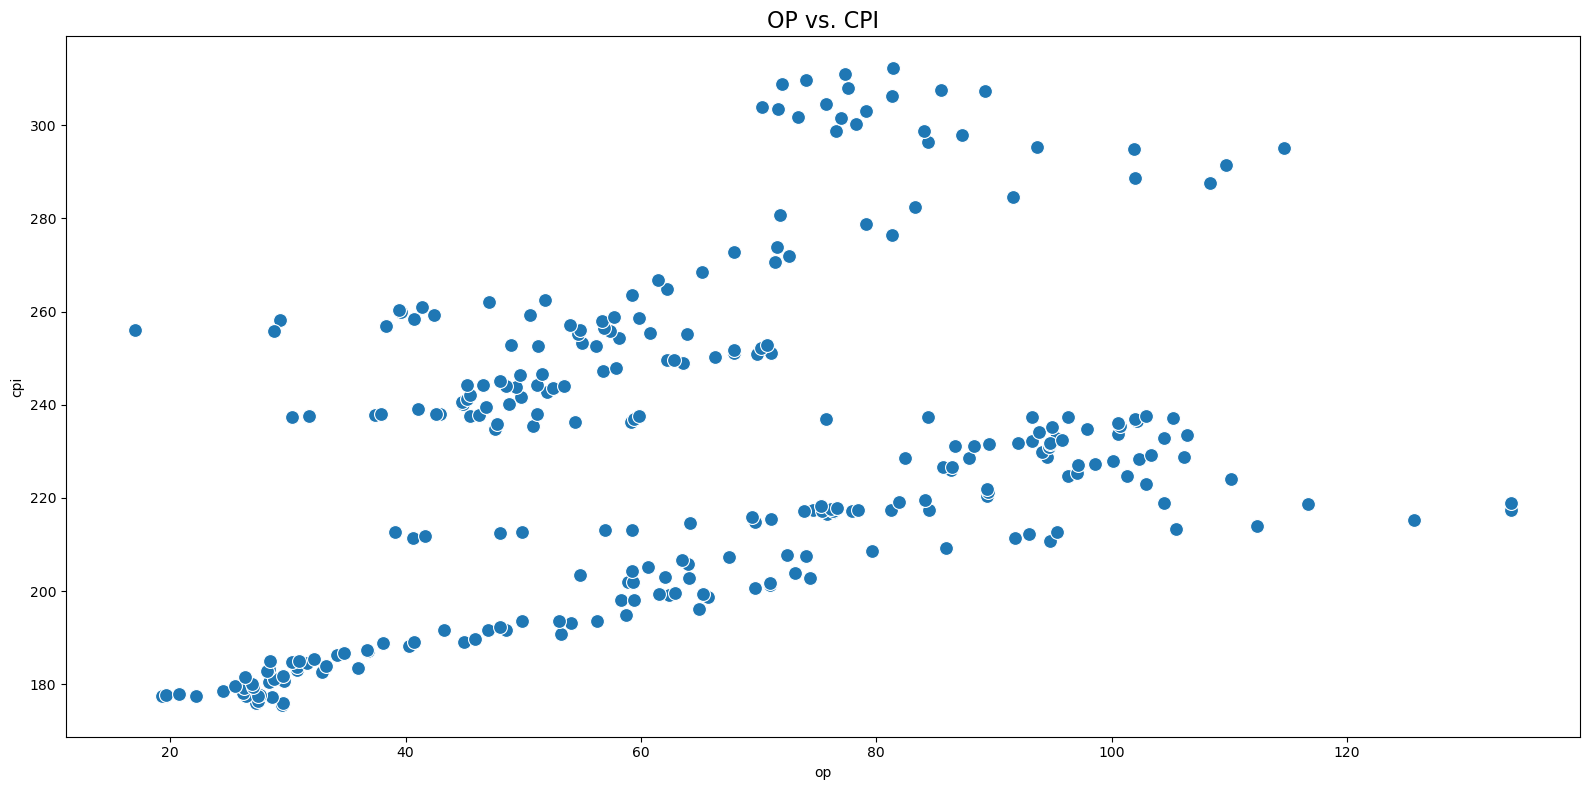

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


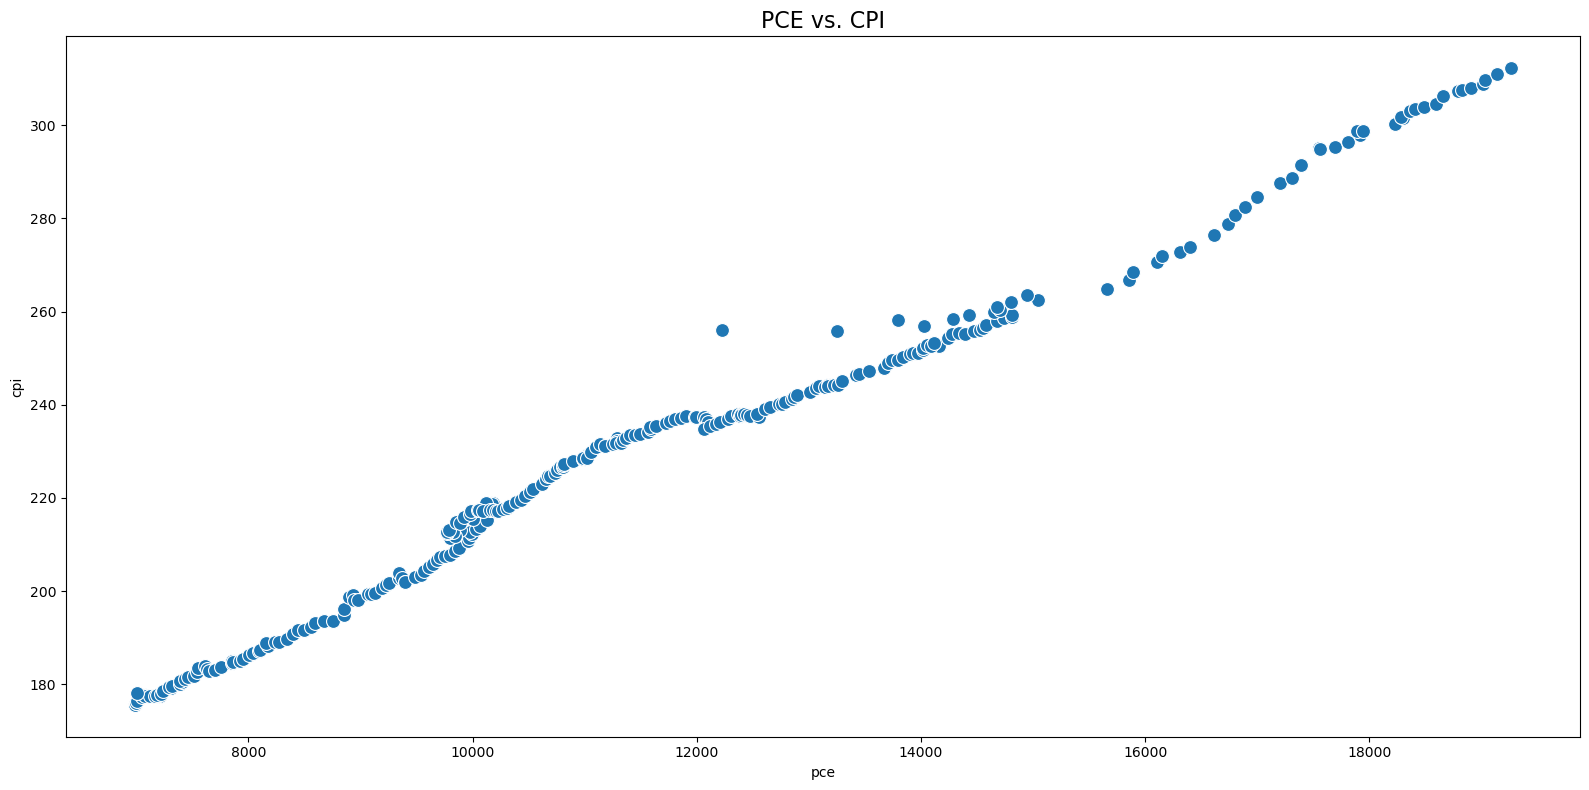

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


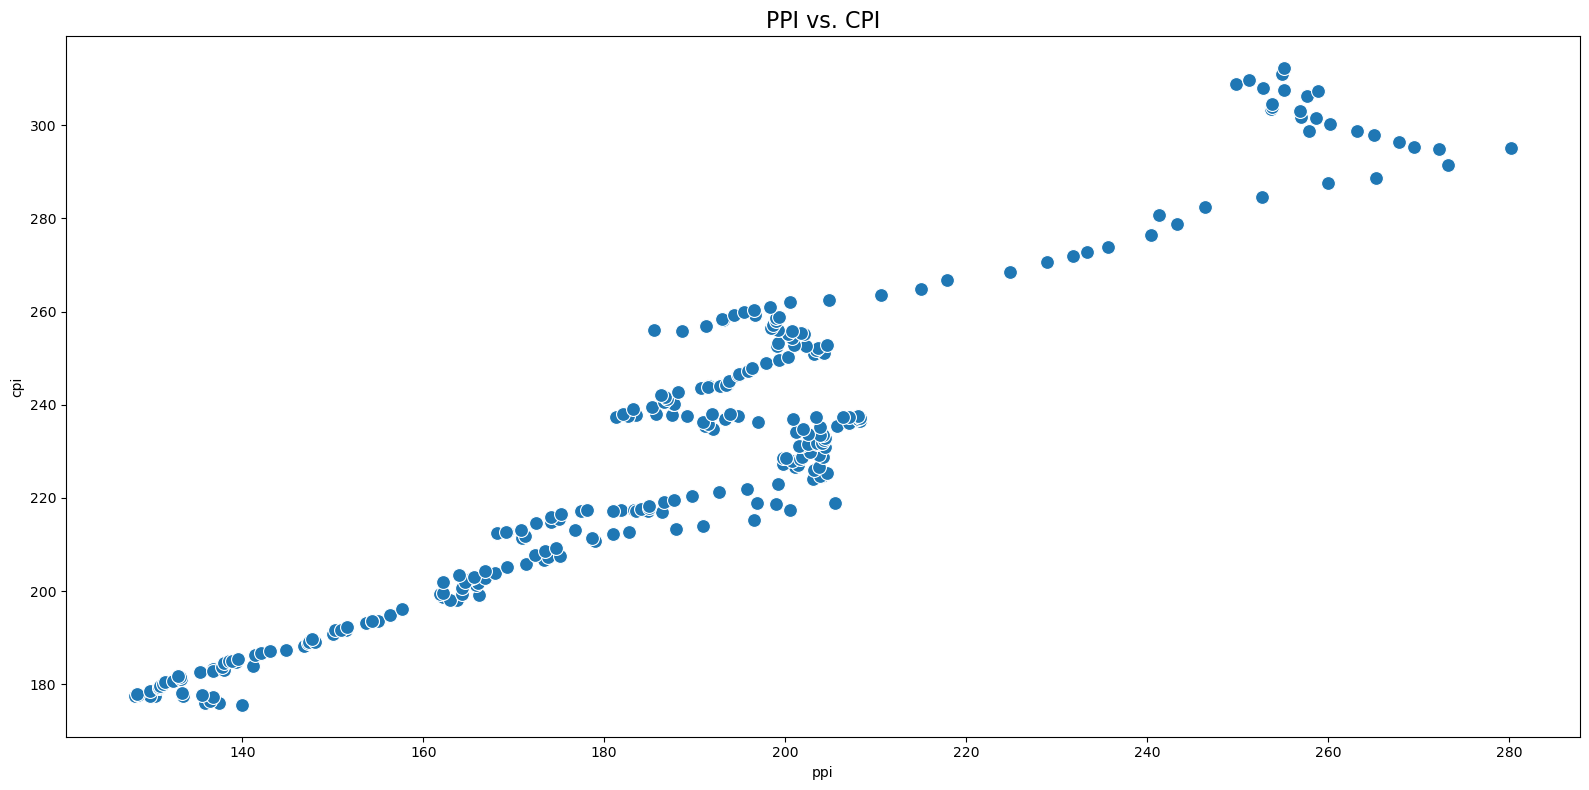

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


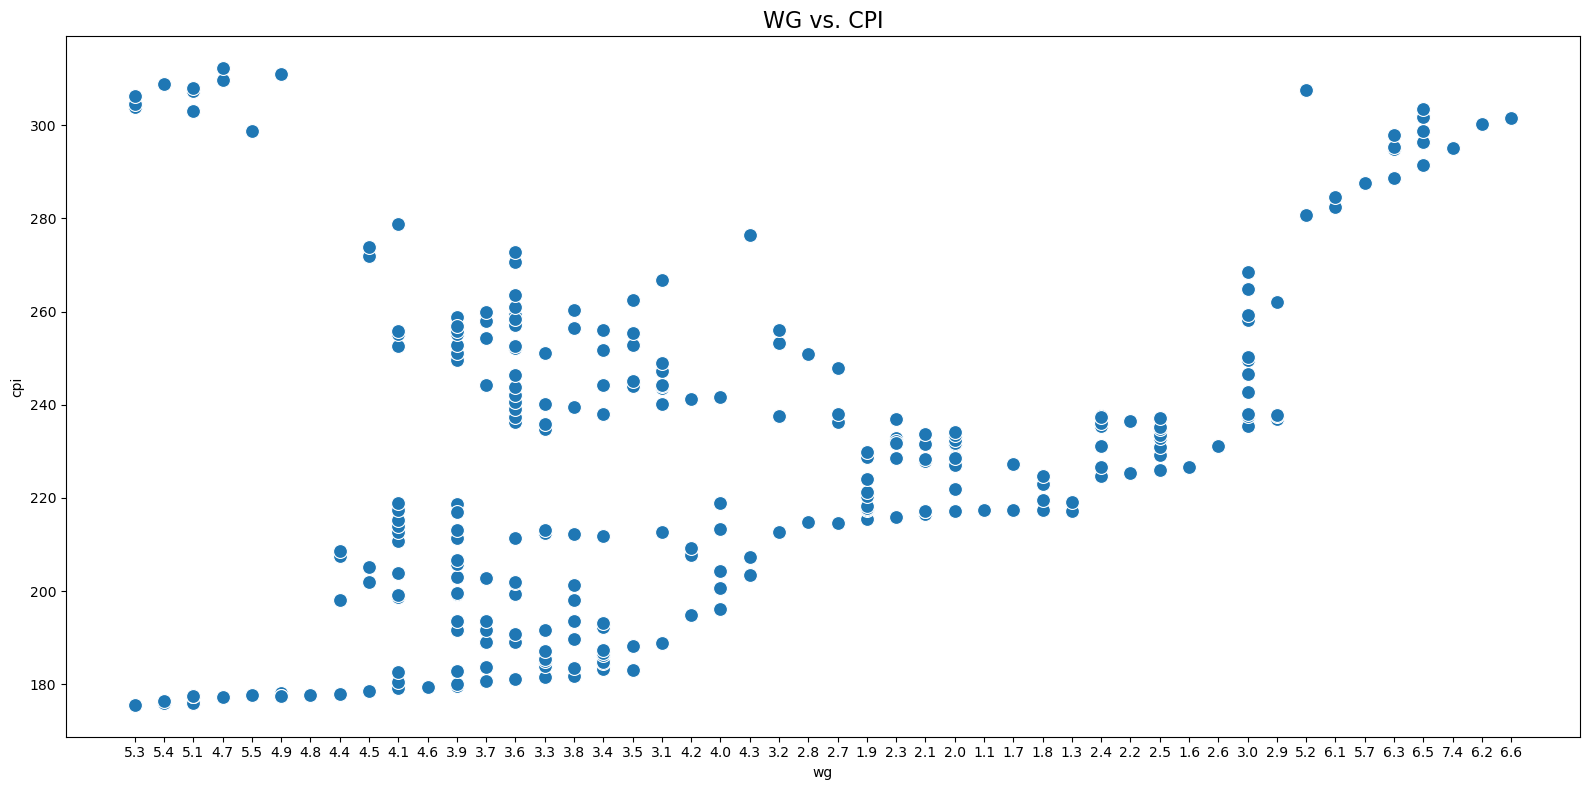

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


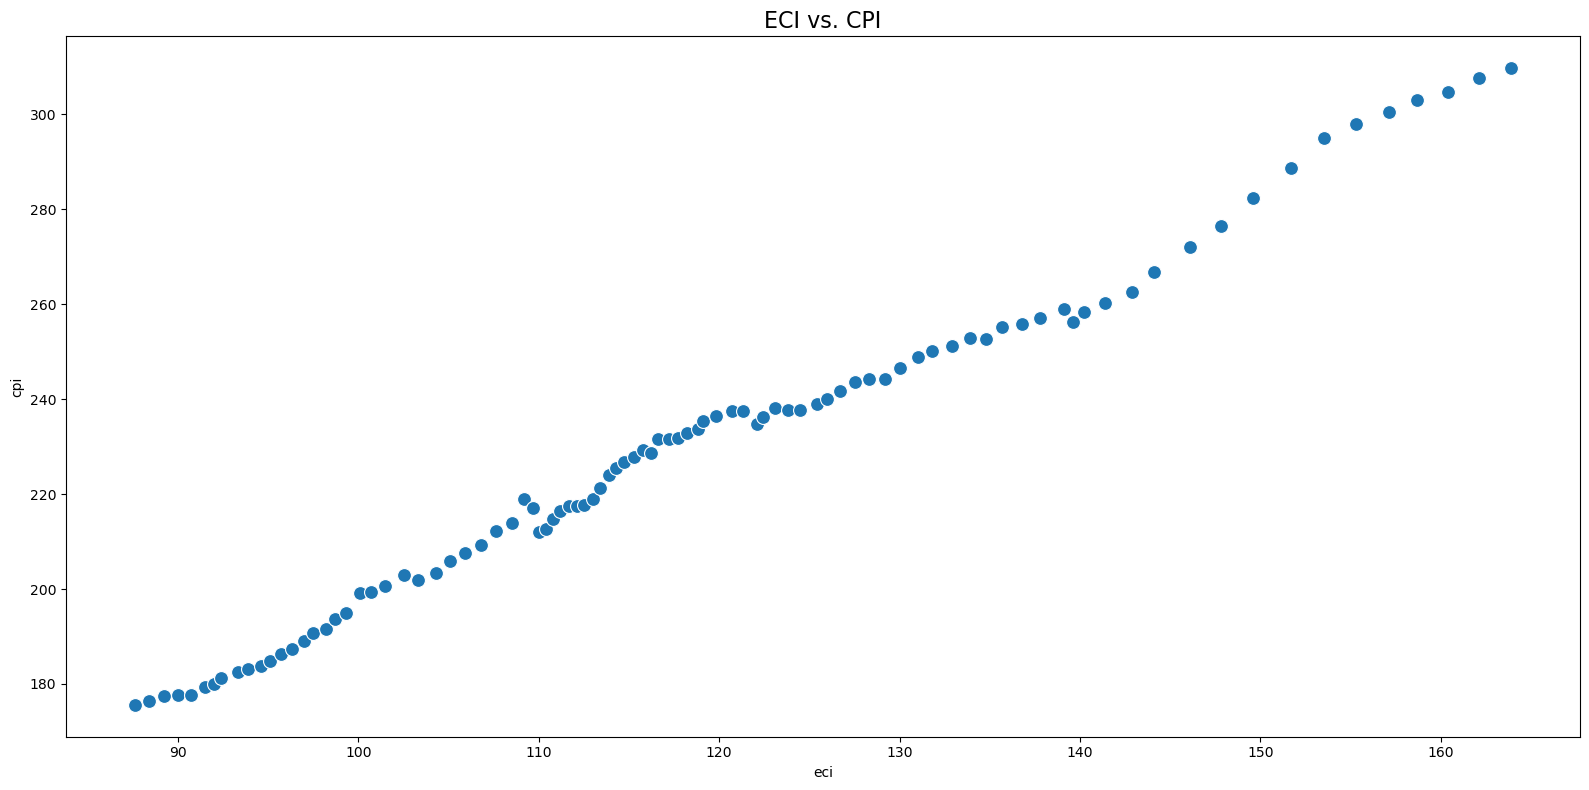

/var/folders/sy/rrmzxyjd2_v79pjf922dgfpr0000gn/T/ipykernel_872/1063137788.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})


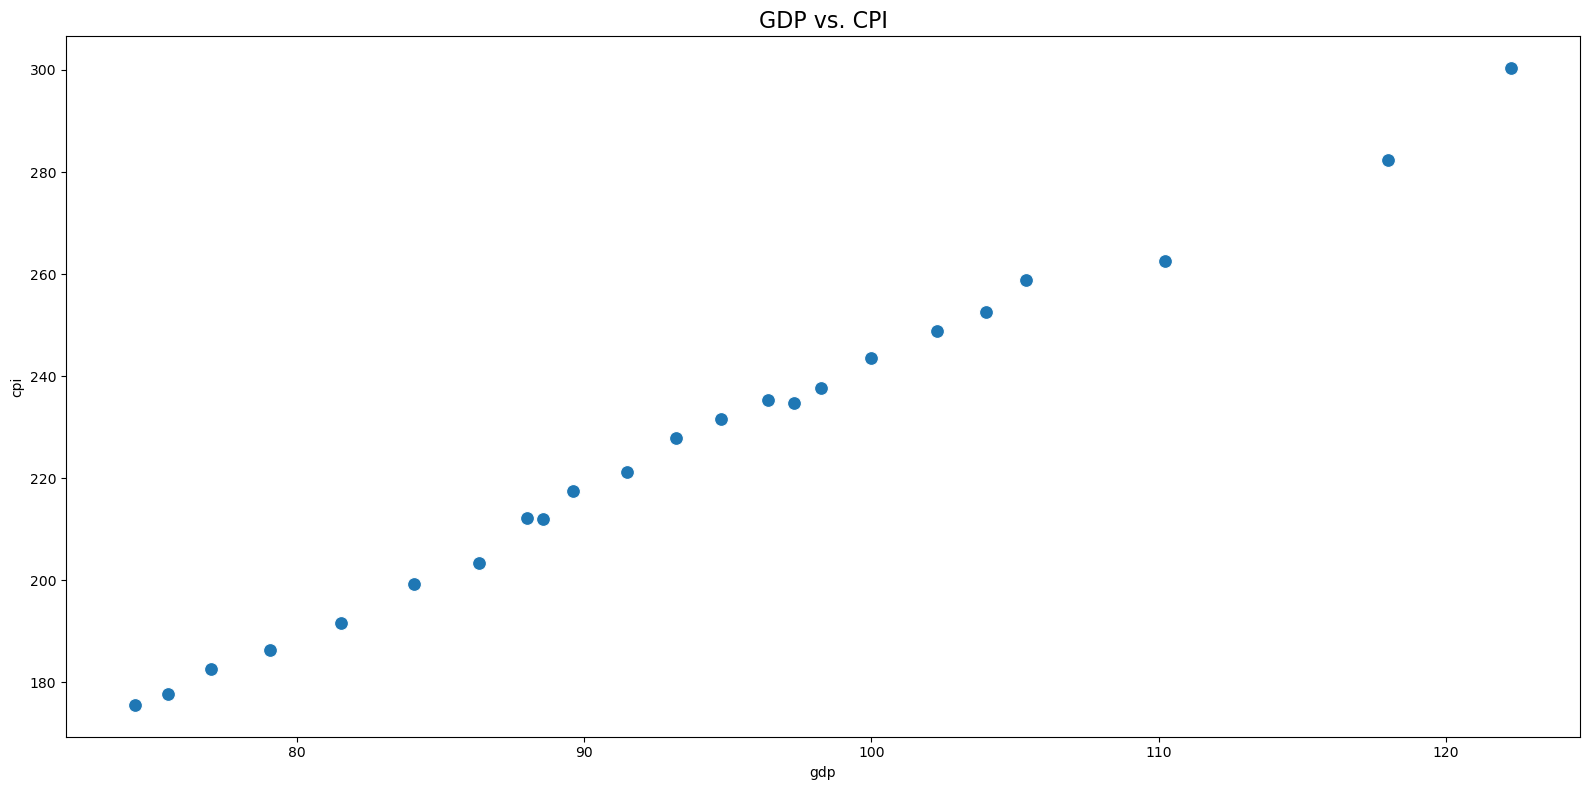

In [58]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    sns.scatterplot(data=df, x = df[column], y = df['cpi'], legend=True, s = 100, palette={'A':'red', 'B': 'blue'})
    plt.title(f"{column.upper()} vs. CPI", fontsize=16)
    plt.tight_layout()
    plt.show()

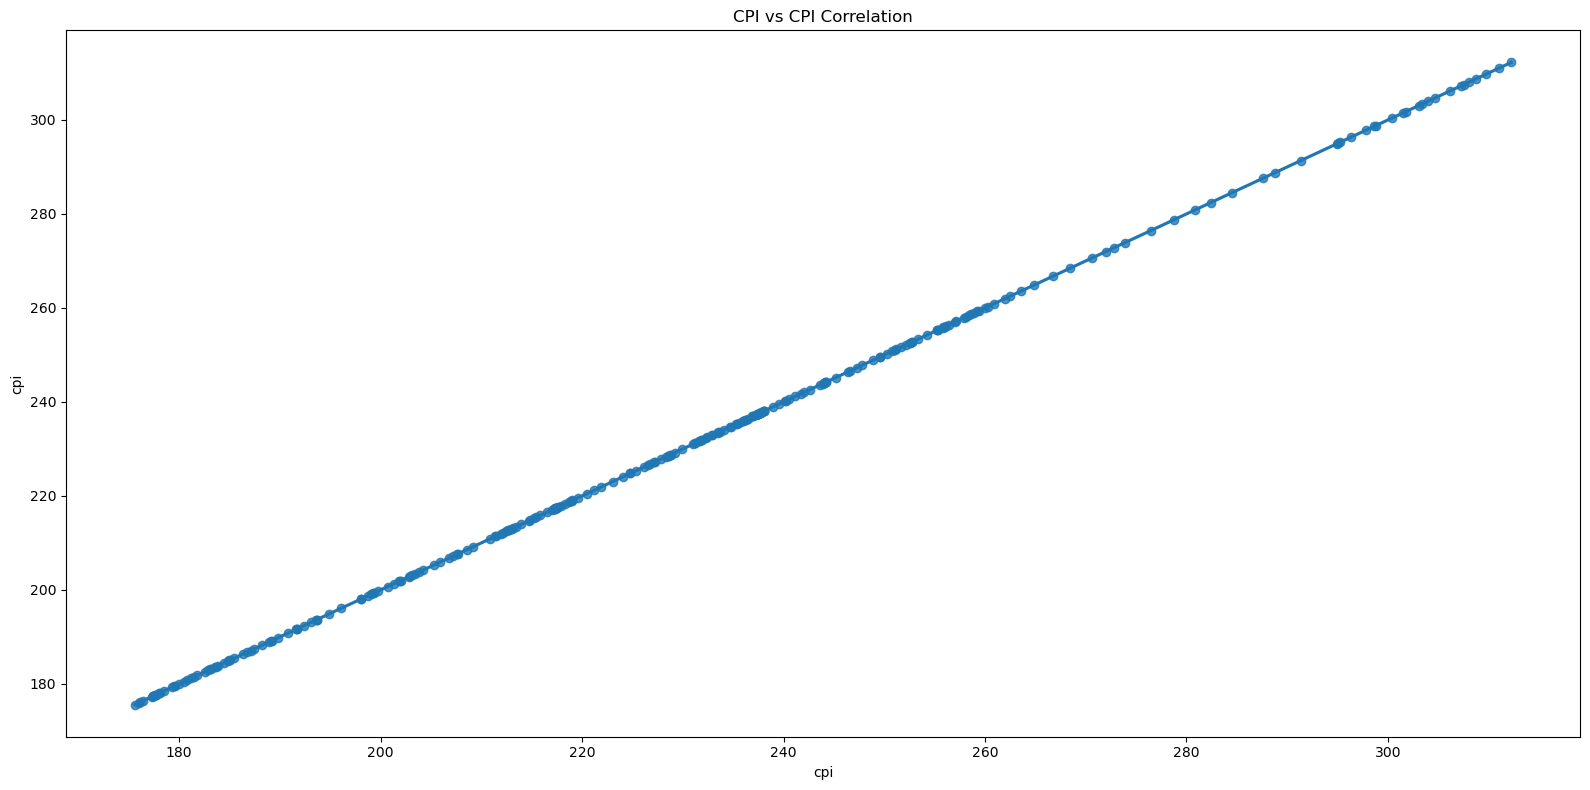

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U9'), dtype('float64')) -> None

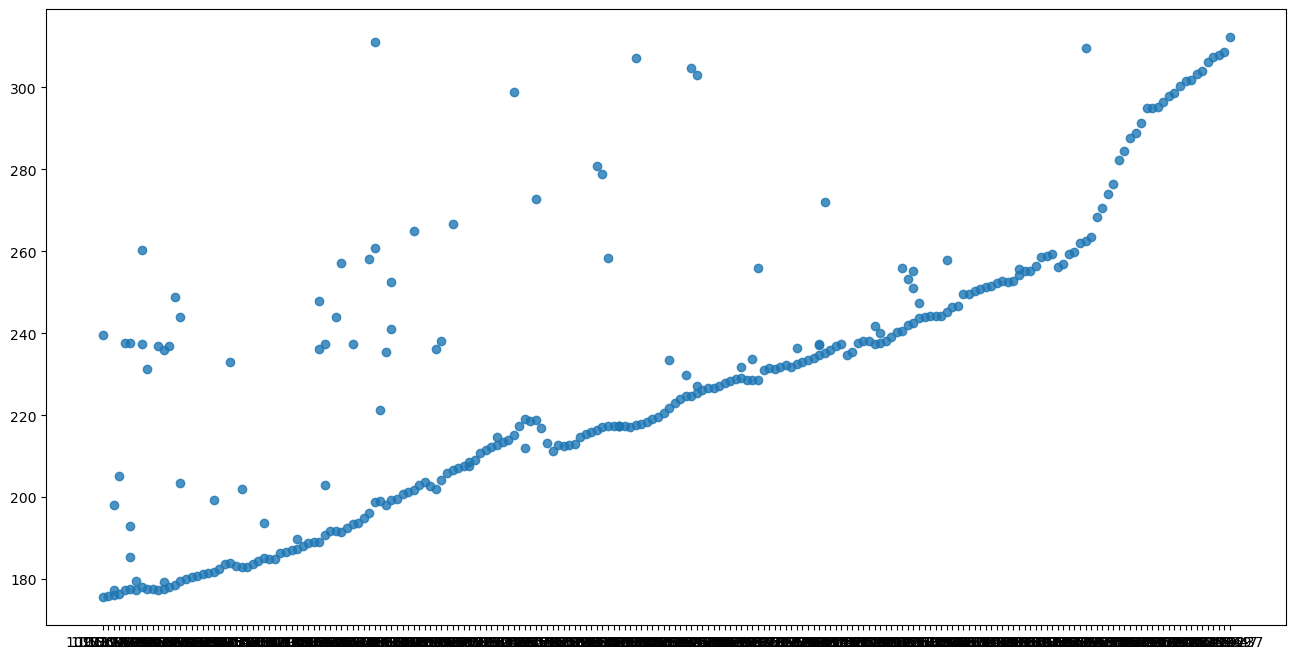

In [59]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    sns.regplot(data=df, x = df[column], y = df['cpi'])
    plt.title(f'CPI vs {column.upper()} Correlation')
    plt.tight_layout()
    plt.show()

In [ ]:
# Identify the indices with the strongest correlation with CPI
cpi_correlations = corr_matrix['cpi'].sort_values(ascending=False)
print("Indices strongly correlated with CPI:\n", cpi_correlations)

Indices strongly correlated with CPI:
 cpi    1.000000
eci    0.994817
pce    0.993714
ppi    0.948008
ipi    0.752755
op     0.401774
gdp    0.309814
wg     0.275584
csi   -0.331033
Name: cpi, dtype: float64


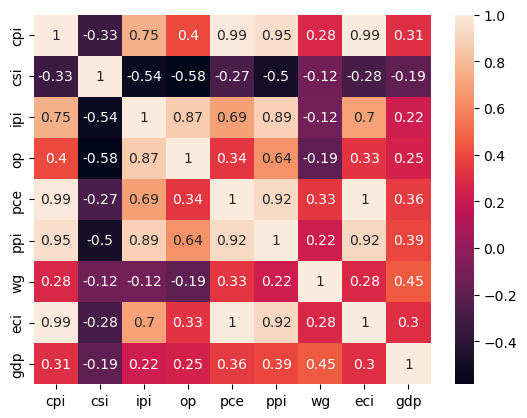

In [ ]:
# drawing heatmap
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [ ]:
df['cpi'].diff() / df['cpi'].shift(1) * 100

DATE
2001-01-01         NaN
2001-04-01    0.701156
2001-07-01    0.282273
2001-10-01   -0.075061
2002-01-01    0.319249
                ...   
2023-01-01    0.925476
2023-04-01    0.751542
2023-07-01    0.846112
2023-10-01    0.674652
2024-01-01    0.938227
Freq: QS-JAN, Name: cpi, Length: 93, dtype: float64

In [ ]:
df['inflation'] = df['cpi'].pct_change()*100
df

,cpi,csi,ipi,op,pce,ppi,wg,eci,gdp,inflation
DATE,,,,,,,,,,
2001-01-01,175.900000,92.266667,99.566667,28.769013,6995.300000,137.766667,5.266667,87.6,46.55172,NaN
2001-04-01,177.133333,91.000000,97.800000,27.888399,7042.233333,136.233333,5.200000,88.4,41.37931,0.701156
2001-07-01,177.633333,88.566667,96.000000,26.704912,7070.333333,133.366667,5.033333,89.2,27.58621,0.282273
2001-10-01,177.500000,85.133333,92.466667,20.370715,7187.300000,129.400000,4.966667,90.0,22.41379,-0.075061
2002-01-01,178.066667,93.133333,92.000000,21.630329,7217.733333,128.900000,4.566667,90.7,22.41379,0.319249
...,...,...,...,...,...,...,...,...,...,...
2023-01-01,301.203000,64.600000,140.733333,76.209042,18269.566667,258.652667,6.433333,157.1,67.24138,0.925476
2023-04-01,303.466667,62.300000,139.800000,73.702265,18419.000000,254.812667,5.633333,158.7,29.31034,0.751542
2023-07-01,306.034333,69.566667,140.233333,82.126743,18679.500000,256.816333,5.233333,160.4,56.89655,0.846112


In [ ]:
def check_inflation(df, col):
    return df[df[col] > 2.4]

In [ ]:
inflation_periods = check_inflation(df, 'inflation')['inflation']
inflation_periods

DATE
2022-04-01    2.415627
Freq: QS-JAN, Name: inflation, dtype: float64

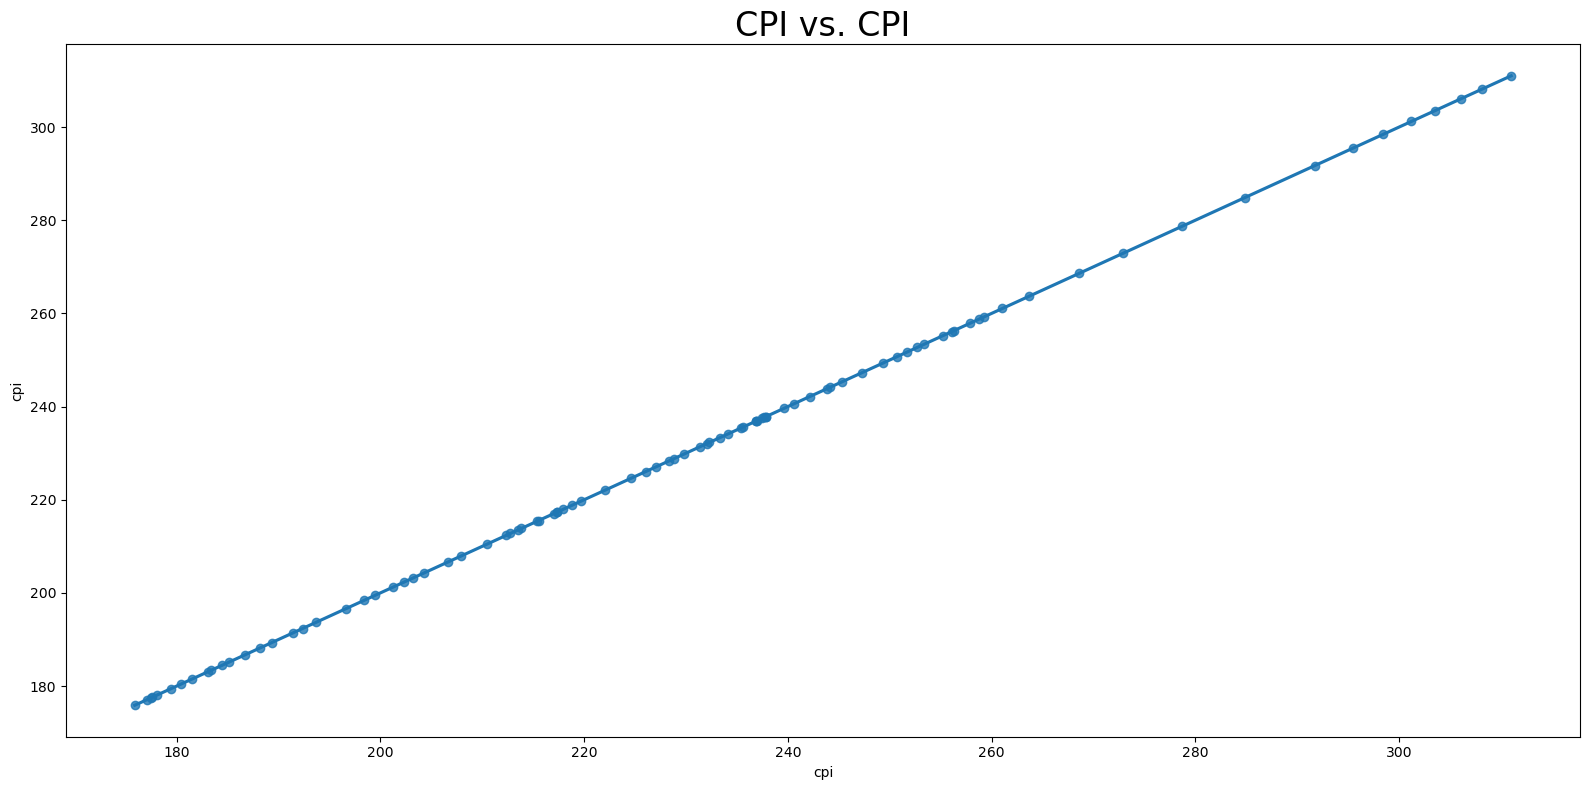

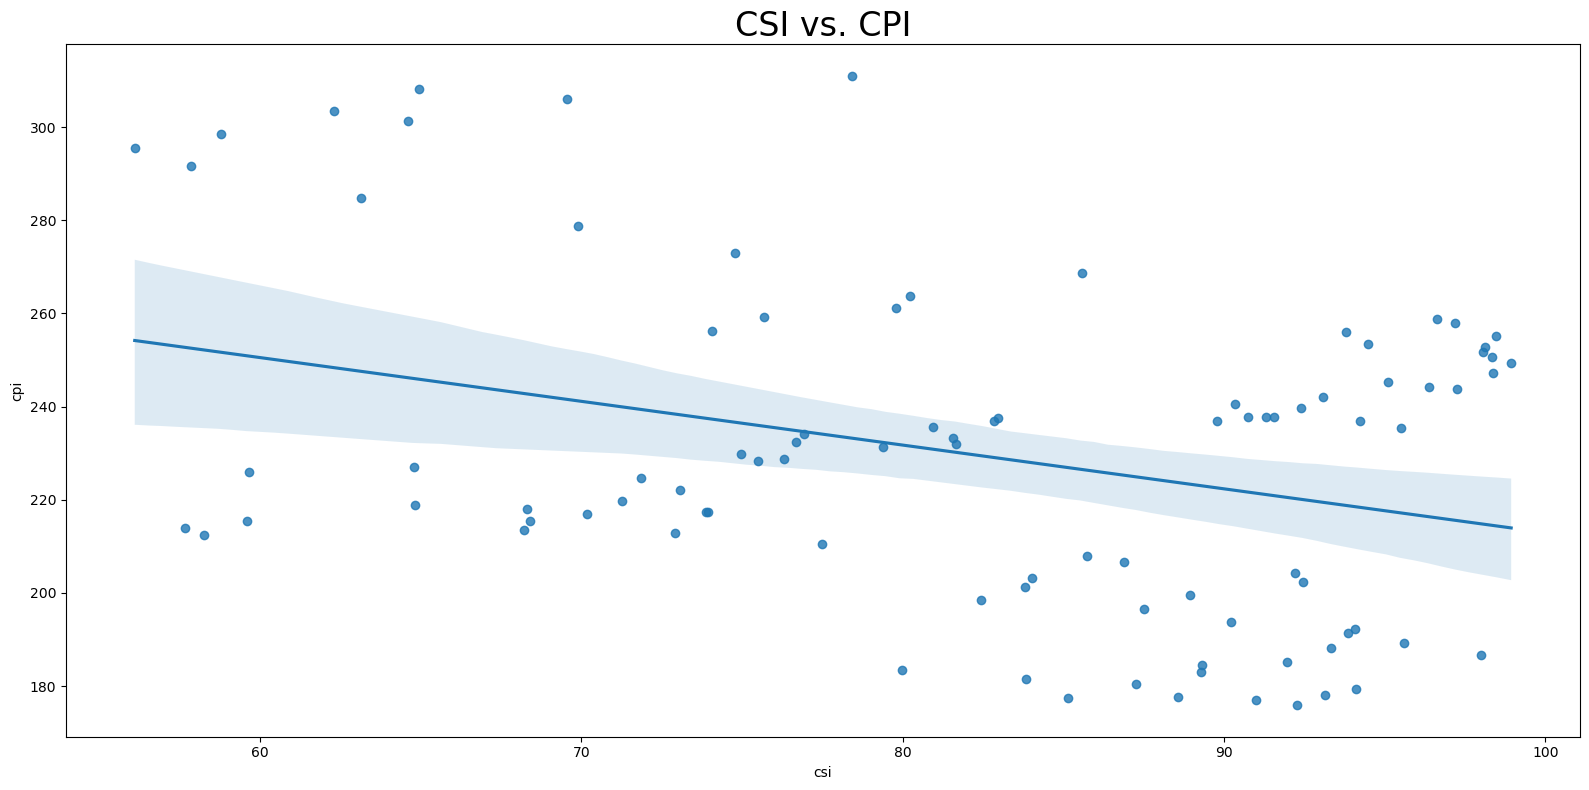

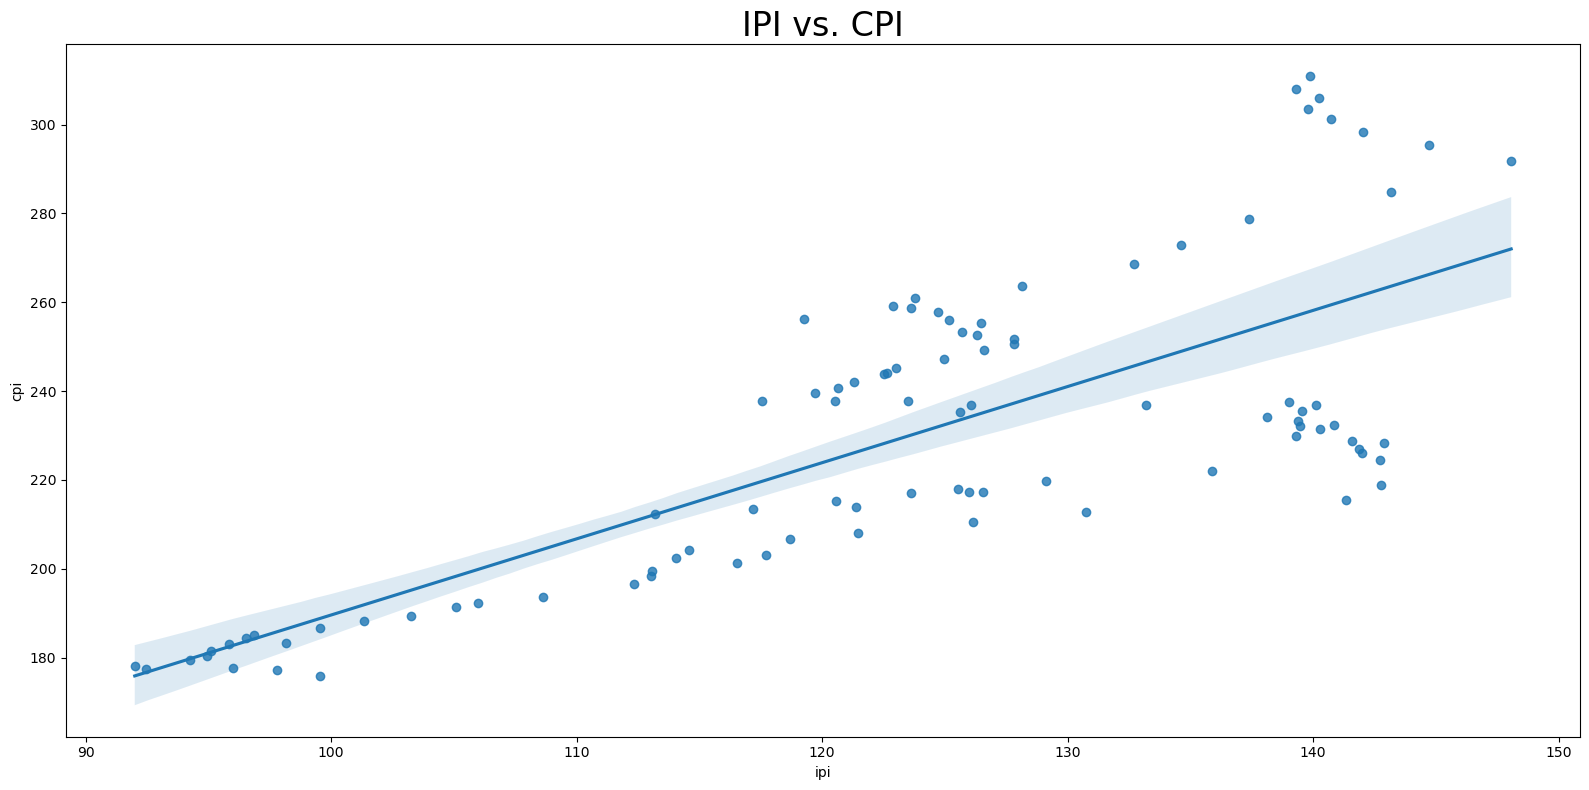

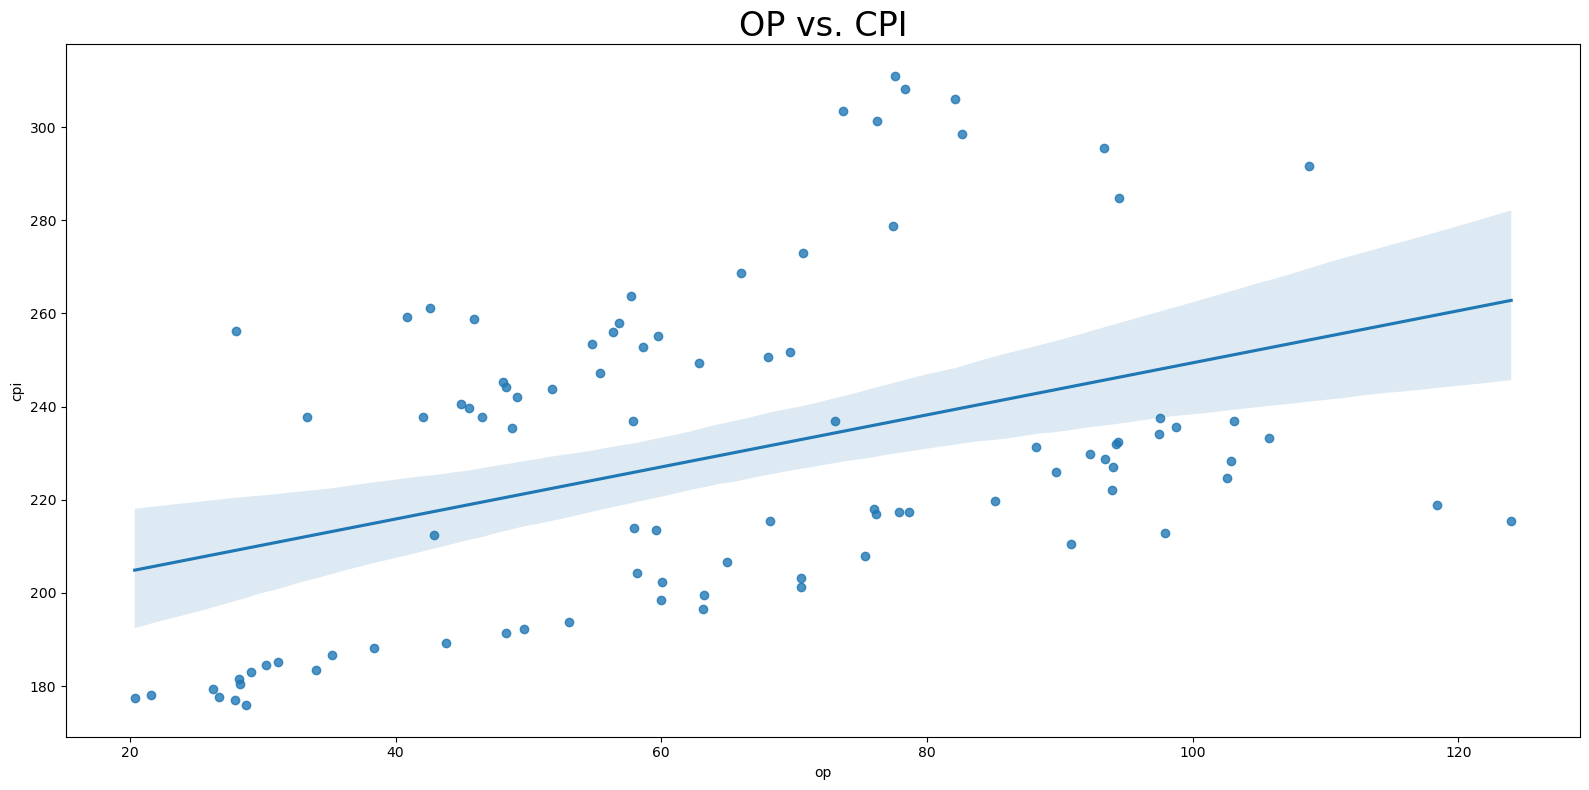

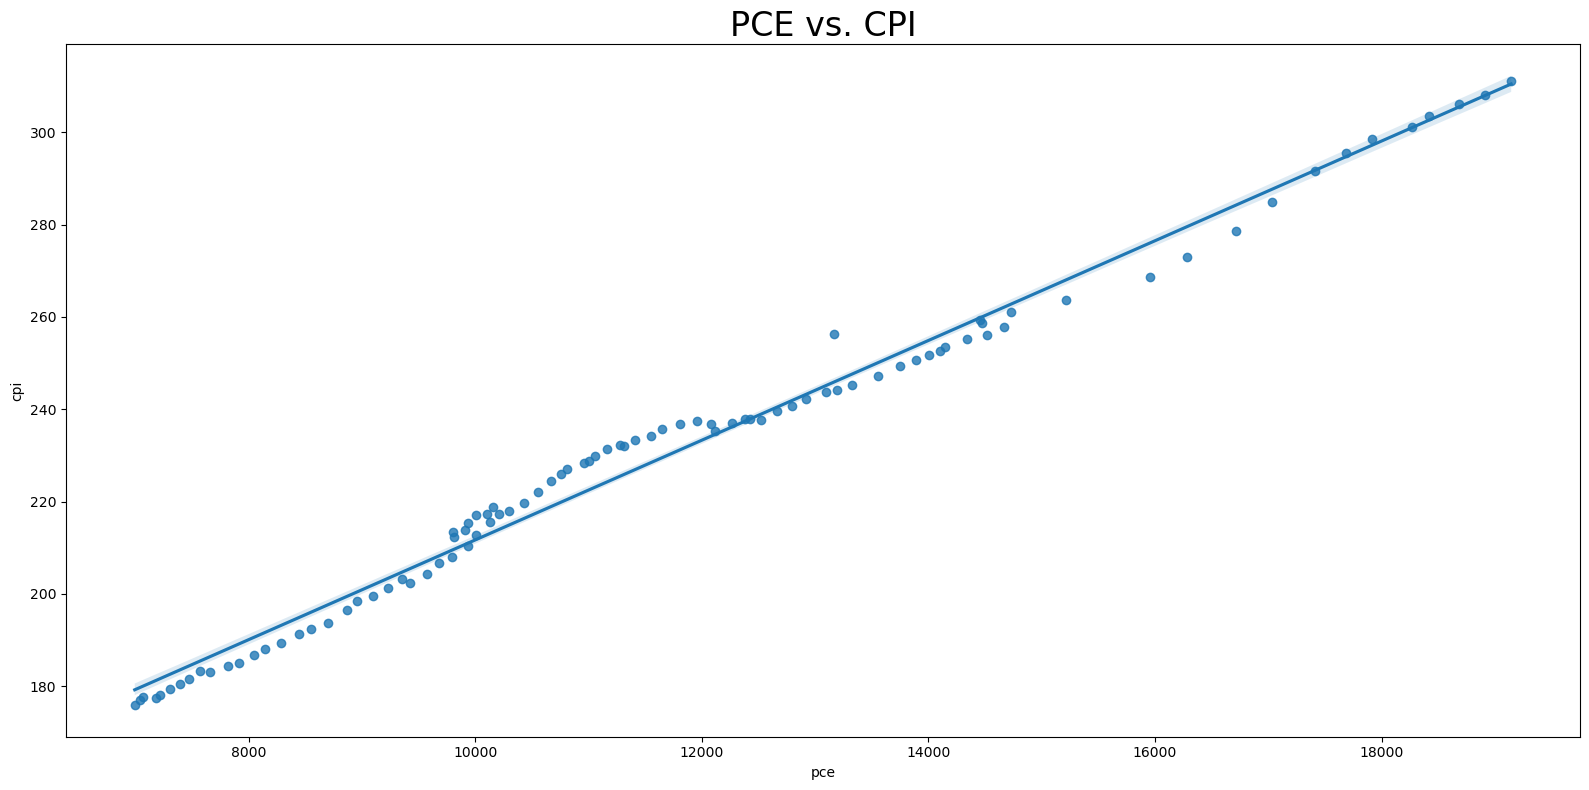

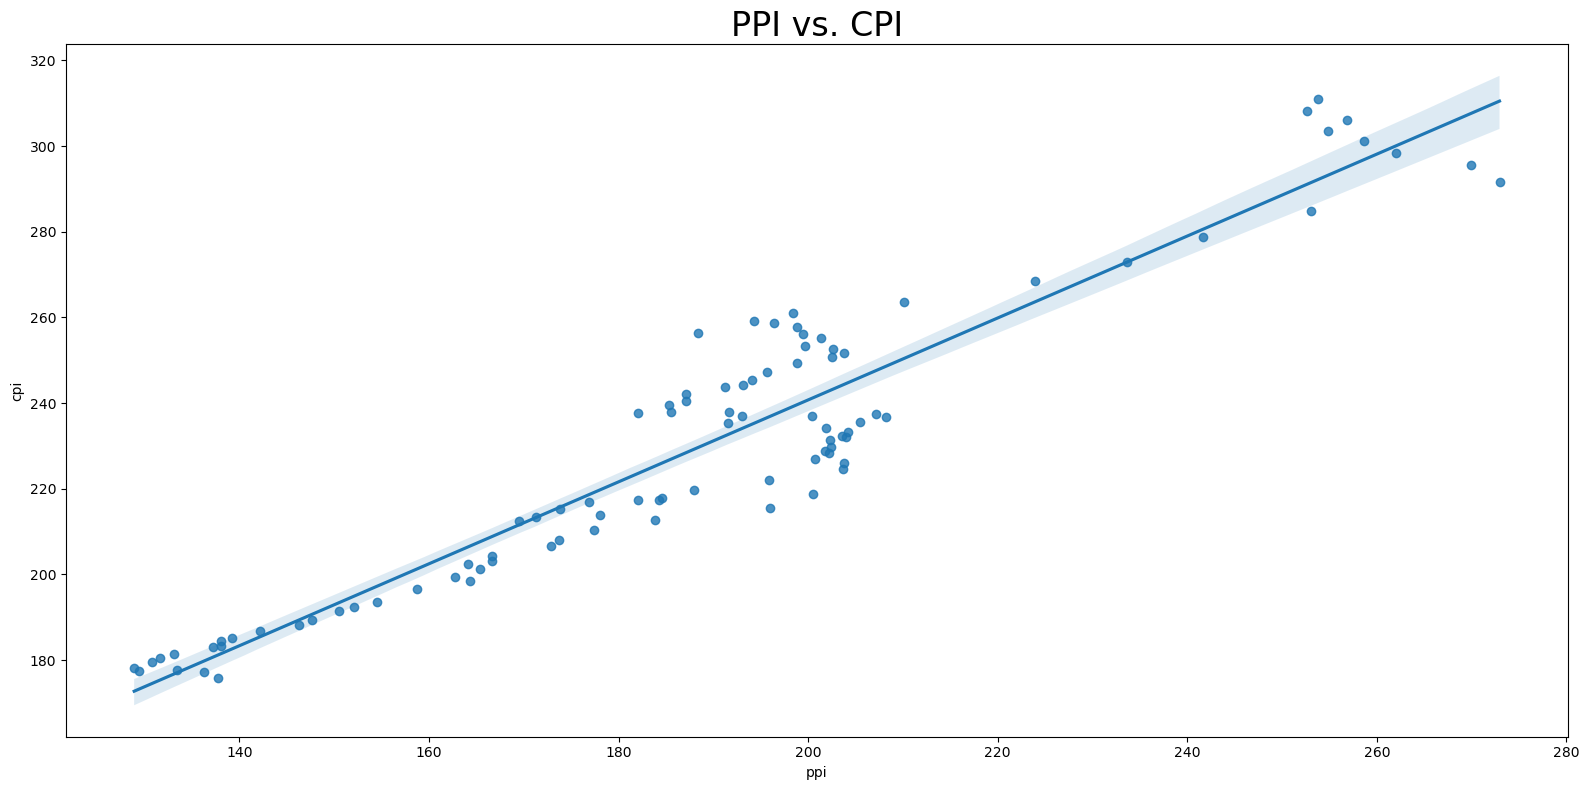

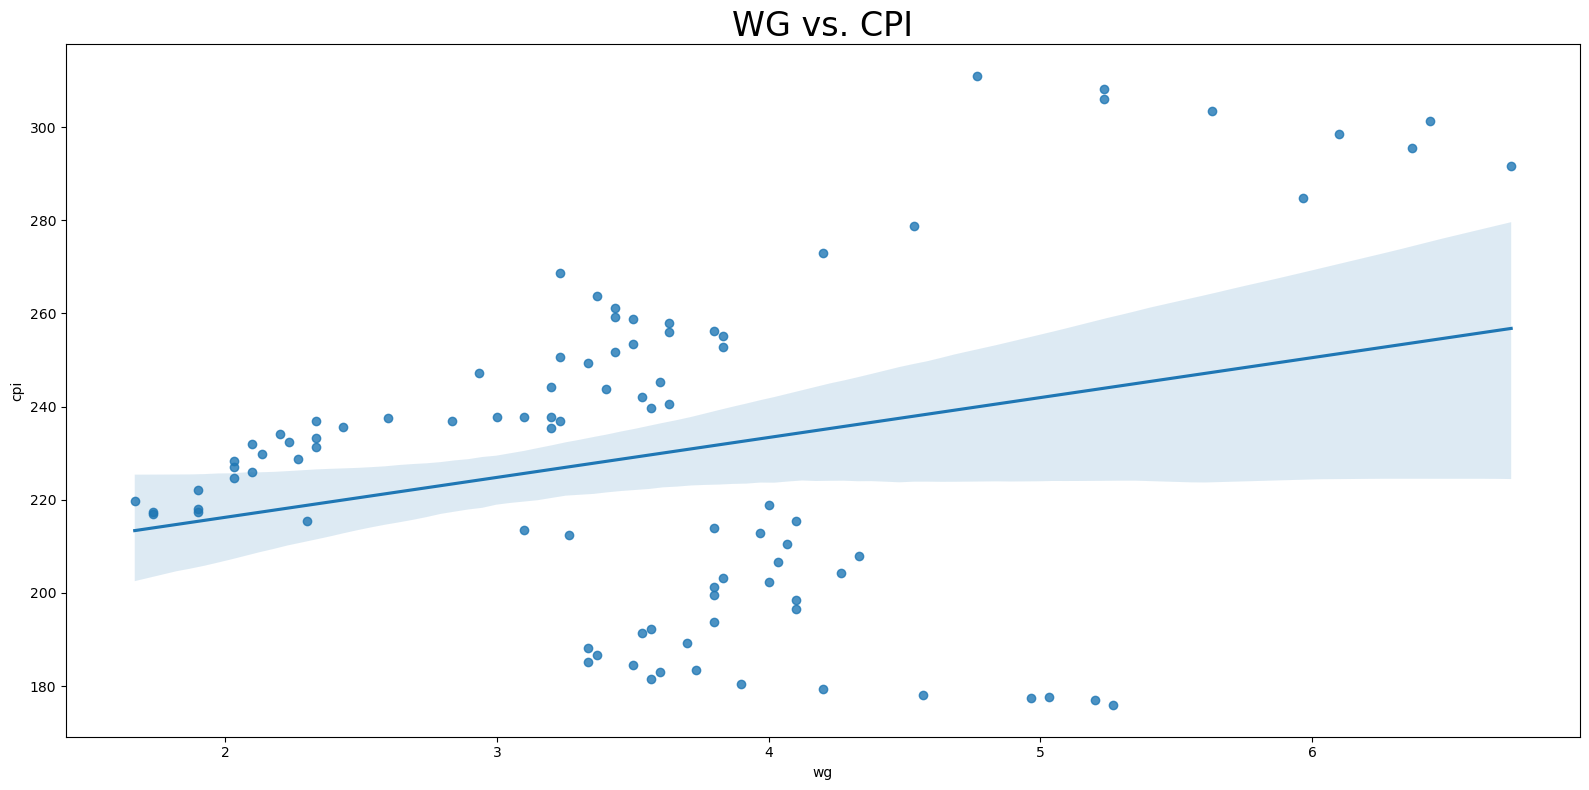

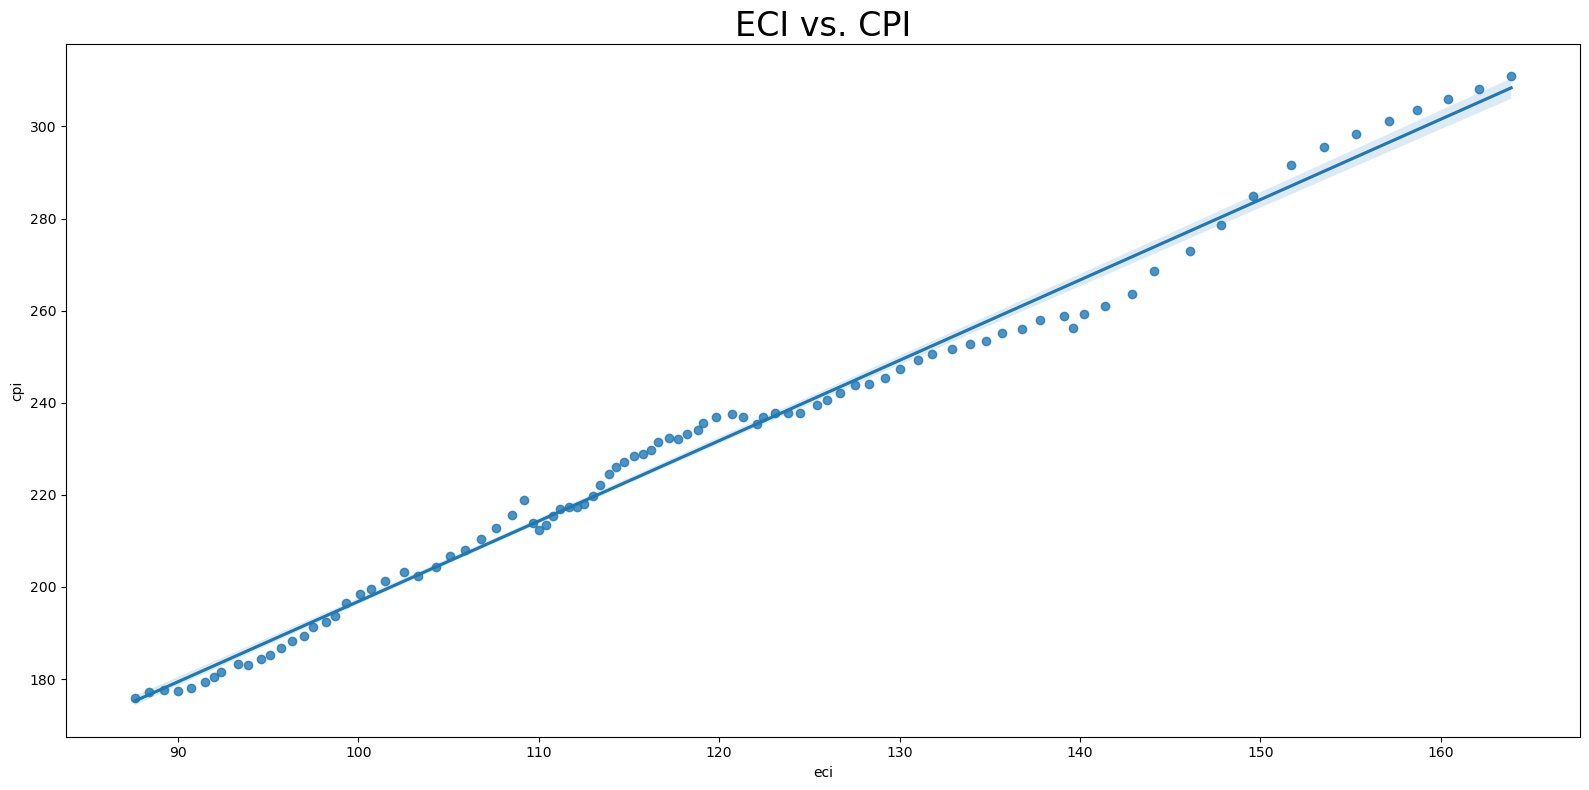

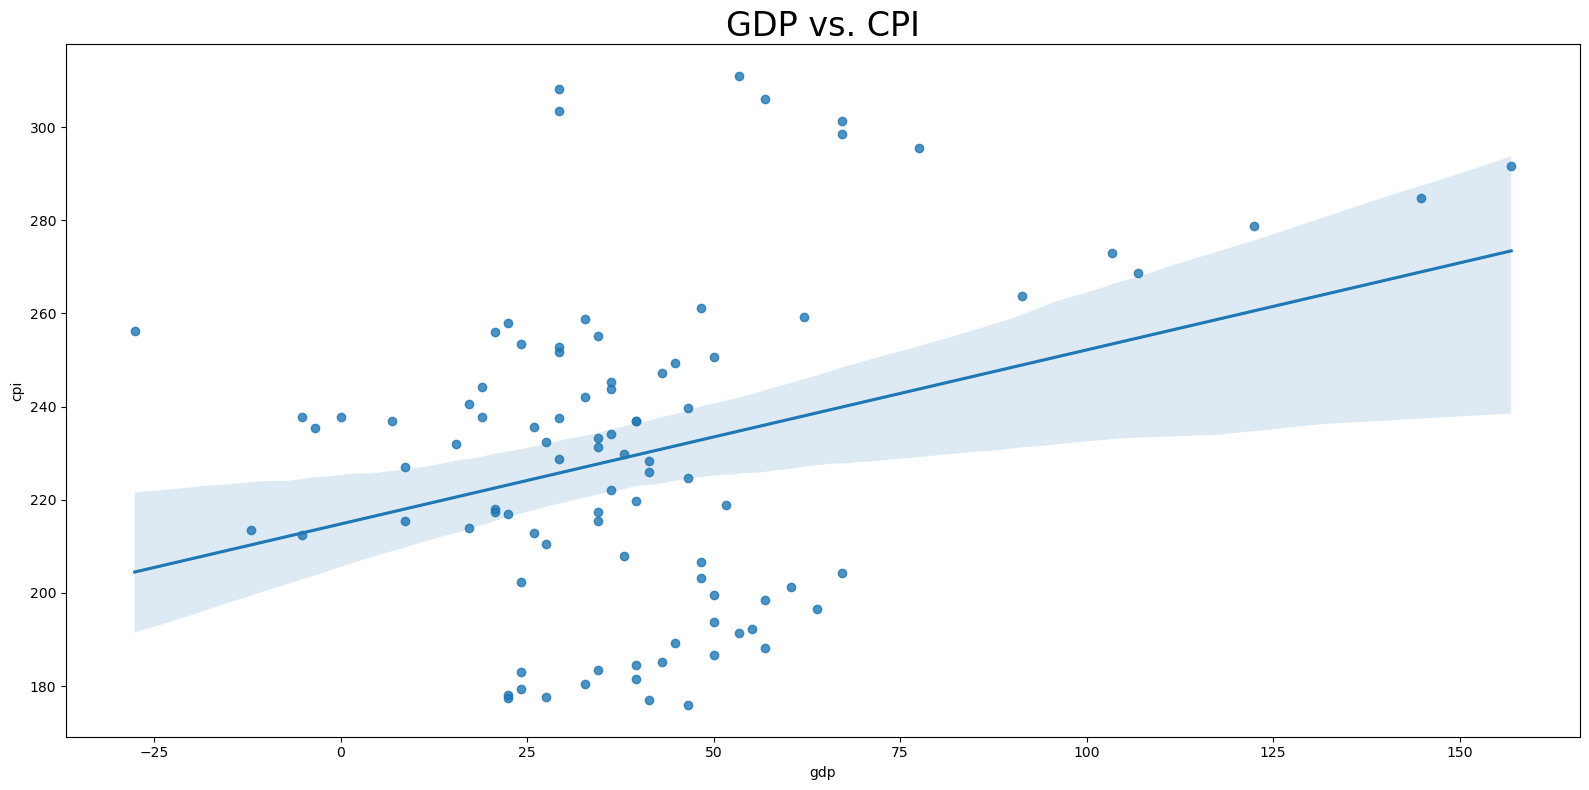

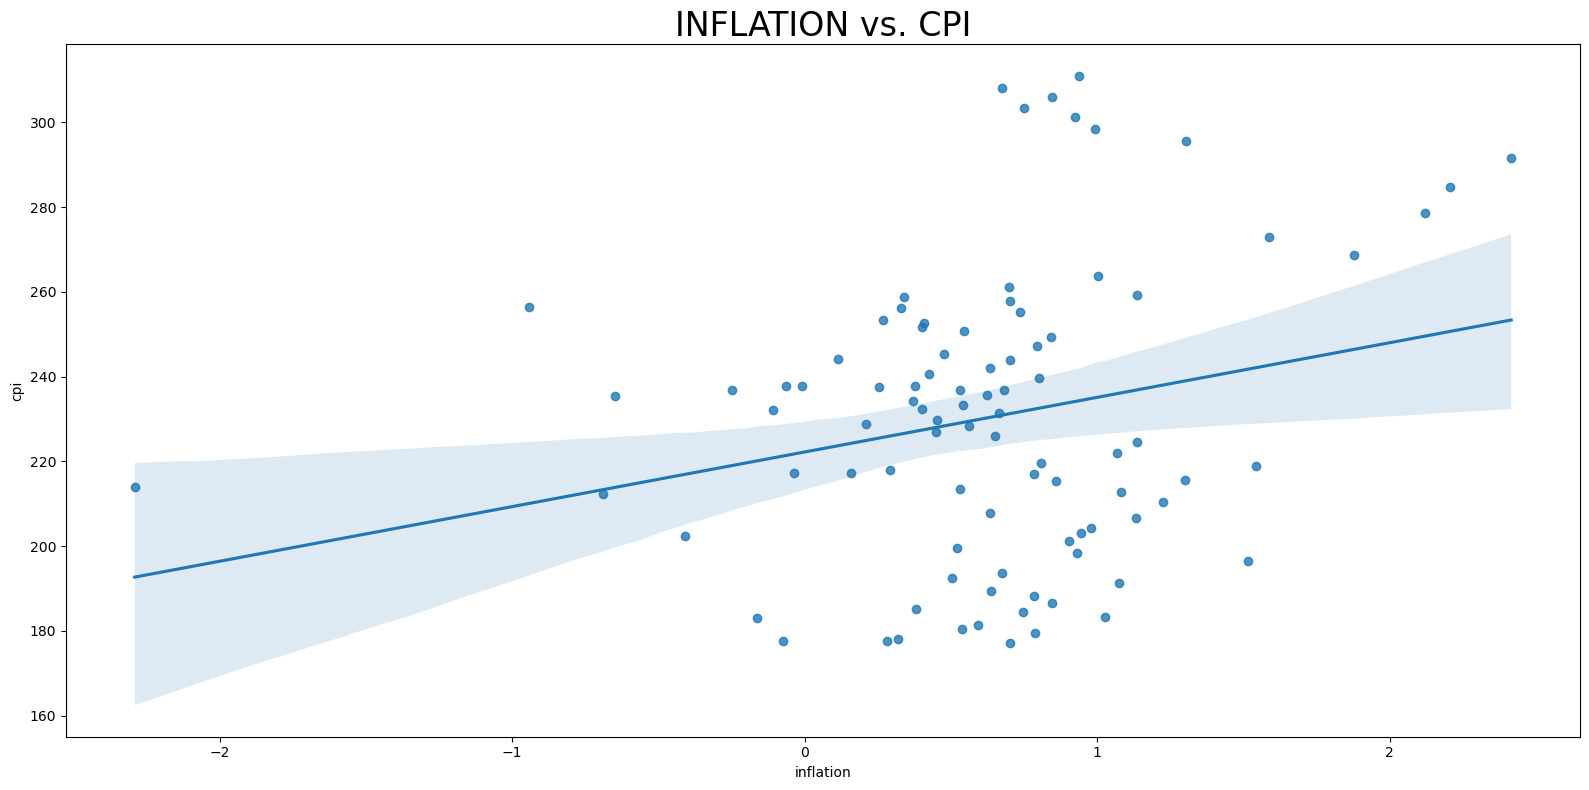

In [ ]:
for column in df.columns:
    plt.figure(figsize=(16, 8))
    plt.title(f"{column.upper()} vs. CPI", fontsize=24)
    sns.regplot(data=df, x = df[column], y = df['cpi'])
    plt.tight_layout()
    plt.show()

In [ ]:
df_2020 =  df[df.index.year >= 2020]

<Axes: xlabel='DATE'>

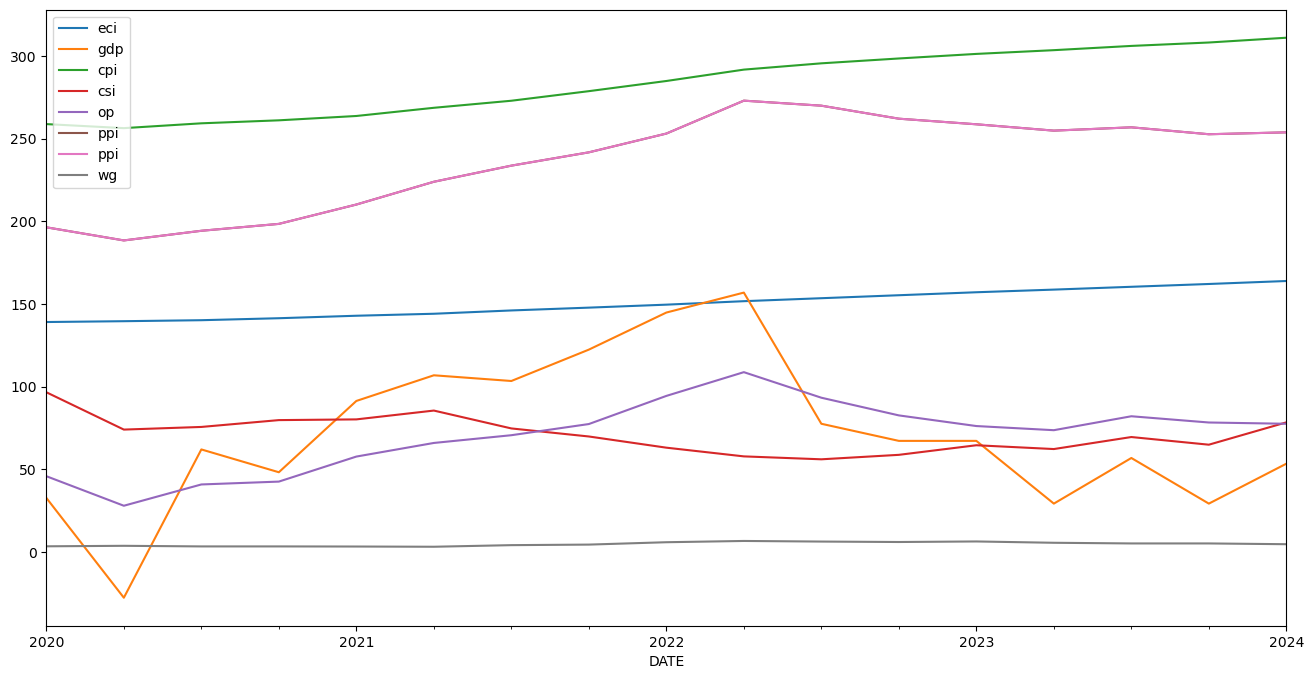

In [ ]:
df_2020[['eci','gdp','cpi','csi','op','ppi','ppi','wg']].plot(figsize=(16, 8))

In [ ]:
df_2020.inflation

DATE
2020-01-01    0.340975
2020-04-01   -0.943447
2020-07-01    1.137484
2020-10-01    0.697419
2021-01-01    1.003896
2021-04-01    1.878229
2021-07-01    1.588598
2021-10-01    2.121856
2022-01-01    2.205275
2022-04-01    2.415627
2022-07-01    1.303594
2022-10-01    0.992186
2023-01-01    0.925476
2023-04-01    0.751542
2023-07-01    0.846112
2023-10-01    0.674652
2024-01-01    0.938227
Freq: QS-JAN, Name: inflation, dtype: float64

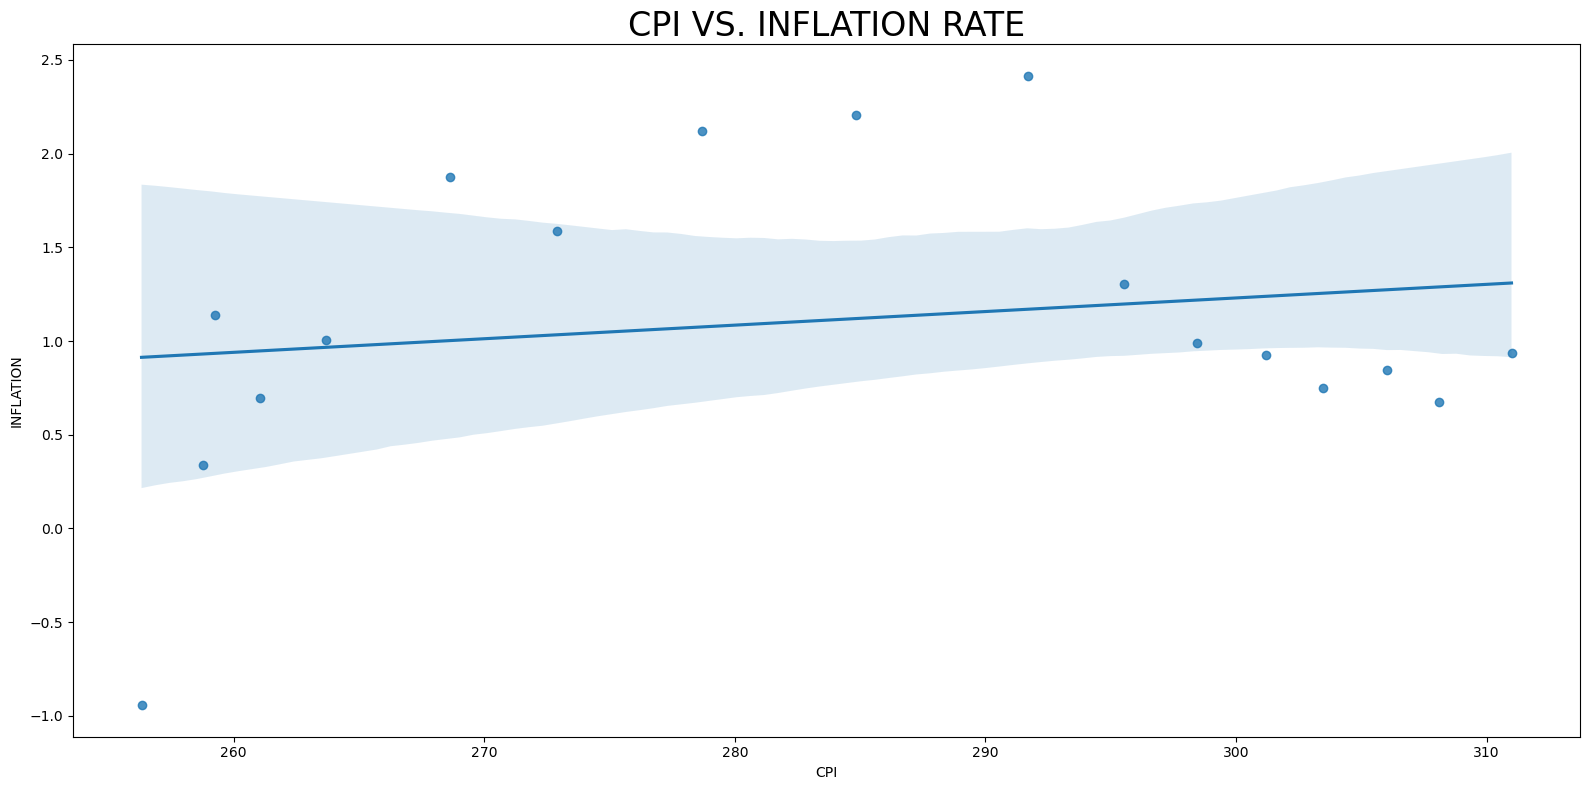

In [ ]:
plt.figure(figsize=(16, 8))
sns.regplot(y=df_2020['inflation'], x=df_2020['cpi'])
plt.title(f"CPI VS. INFLATION RATE", fontsize=24)
plt.ylabel('INFLATION')
plt.xlabel('CPI')
plt.tight_layout()
plt.show()

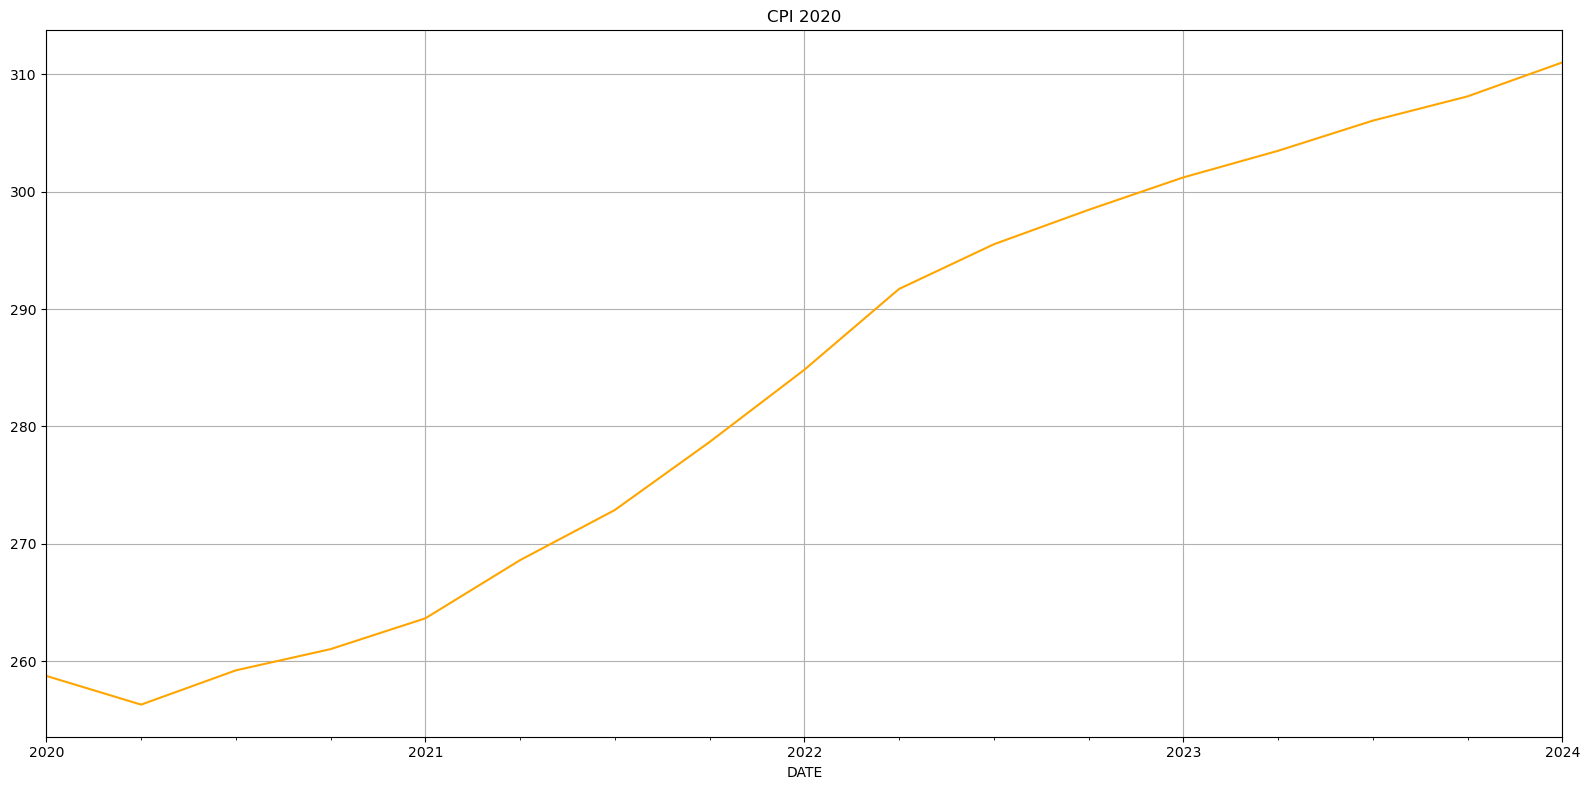

In [ ]:
df_2020.cpi.plot(figsize=(16, 8),color="orange")
plt.title('CPI 2020')
plt.grid(True)
plt.tight_layout()

In [ ]:
df_2020


In [ ]:
df_2020['inflation'].rolling(window=4).mean()

DATE
2020-01-01         NaN
2020-04-01         NaN
2020-07-01         NaN
2020-10-01    0.308108
2021-01-01    0.473838
2021-04-01    1.179257
2021-07-01    1.292035
2021-10-01    1.648145
2022-01-01    1.948489
2022-04-01    2.082839
2022-07-01    2.011588
2022-10-01    1.729170
2023-01-01    1.409221
2023-04-01    0.993200
2023-07-01    0.878829
2023-10-01    0.799445
2024-01-01    0.802633
Freq: QS-JAN, Name: inflation, dtype: float64

In [ ]:
df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3156\3083237435.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2020['CPI_Rolling_Mean'] = df['cpi'].rolling(window=window_size).mean()


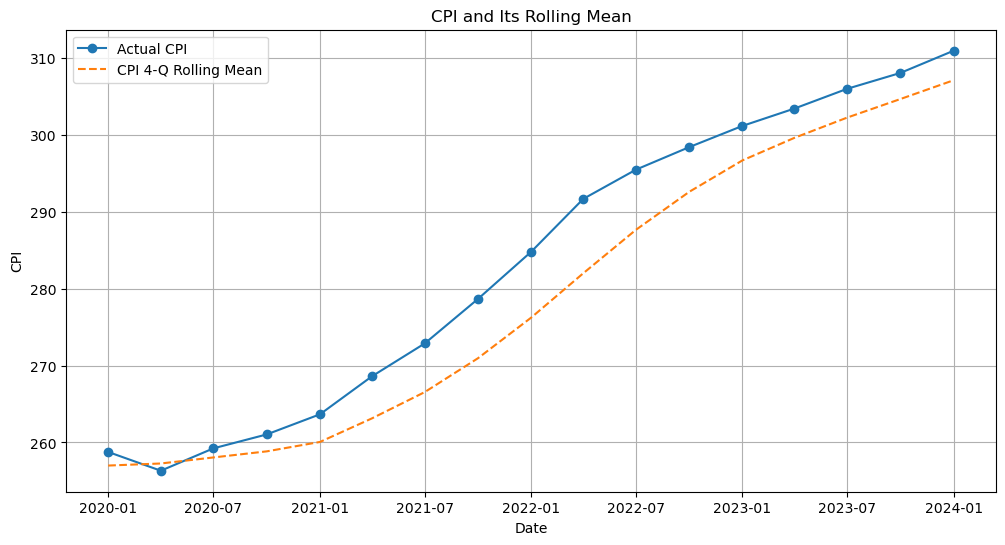

In [ ]:
# Set window size for rolling mean
window_size = 4  # 12 months window

# Calculate rolling mean of CPI
df_2020['CPI_Rolling_Mean'] = df['cpi'].rolling(window=window_size).mean()

# Plot actual CPI and its rolling mean
plt.figure(figsize=(12, 6))
plt.plot(df_2020.index, df_2020['cpi'], label='Actual CPI', marker='o')
plt.plot(df_2020.index, df_2020['CPI_Rolling_Mean'], label=f'CPI {window_size}-Q Rolling Mean', linestyle='--')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.title('CPI and Its Rolling Mean')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3156\3001863651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2020['CPI_Inflation_Rolling_Mean'] = df['inflation'].rolling(window=window_size).mean()


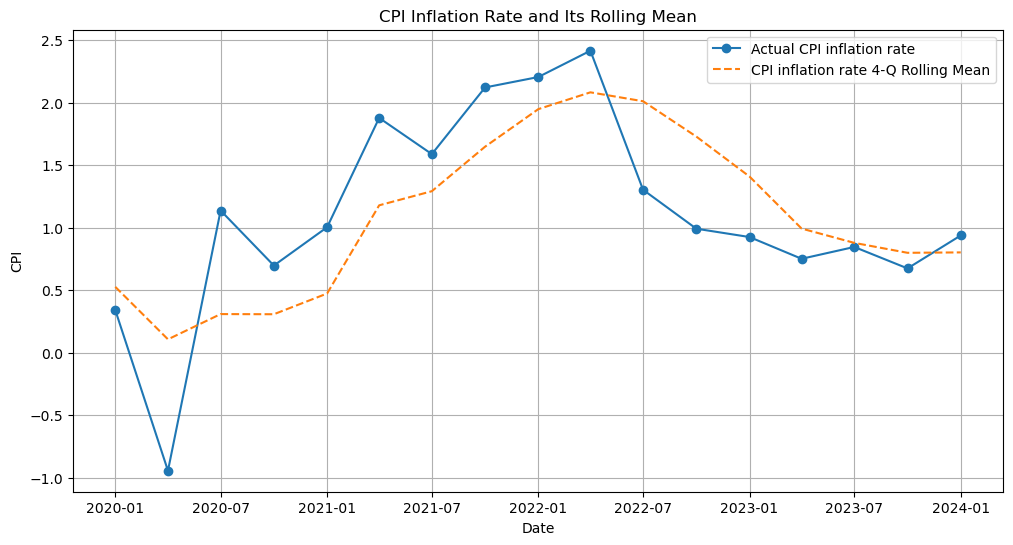

In [ ]:


# Calculate rolling mean of CPI
df_2020['CPI_Inflation_Rolling_Mean'] = df['inflation'].rolling(window=window_size).mean()
plt.figure(figsize=(12, 6))
plt.plot(df_2020.index, df_2020['inflation'], label='Actual CPI inflation rate', marker='o')
plt.plot(df_2020.index, df_2020['CPI_Inflation_Rolling_Mean'], label=f'CPI inflation rate {window_size}-Q Rolling Mean', linestyle='--')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.title('CPI Inflation Rate and Its Rolling Mean')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
df_2020

NameError: name 'df_2020' is not defined

In [61]:
predicted_next_Q = df_2020['CPI_Inflation_Rolling_Mean'].iloc[-1]
print(f'predicted inflation rate for next Quarter is {predicted_next_Q}')

NameError: name 'df_2020' is not defined